In [23]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import time
import gc
import pickle
from datetime import datetime
import cmaps
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from wave_tools.filters import CCKWFilter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
# 配置参数
CACHE_DIR = "./cache/kelvin_wave/"
REGRESSION_CACHE_DIR = os.path.join(CACHE_DIR, "latent_heat_flux_regression_composite")
FIG_SAVE_DIR = "./figures/latent_heat_flux_composite/"

# 创建必要的目录
for d in [CACHE_DIR, REGRESSION_CACHE_DIR, FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)

# 分析参数
LEAD_LAG_DAYS = 4  
EQUATOR_LAT = slice(0, 10)     # 用于纬向平均的纬度范围（0-10°N）

# 实验列表
EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

print(f"📁 Cache directory: {CACHE_DIR}")
print(f"📁 Regression cache: {REGRESSION_CACHE_DIR}")
print(f"📁 Figure save directory: {FIG_SAVE_DIR}")
print(f"📊 Lead-lag range: {-LEAD_LAG_DAYS} to {LEAD_LAG_DAYS} days")

print("="*80)
print("="*80)
print("🌧️  Precipitation-based Kelvin Wave Regression Composite Analysis")
print("="*80)
print(f"📅 Notebook started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
def load_filtered_data(var_name, exp_list=None):
    """
    加载滤波后的数据
    
    Parameters:
    -----------
    var_name : str
        变量名称 ('pr', 'ua', 'va', 'omega')
    exp_list : list, optional
        实验列表
    
    Returns:
    --------
    data_dict : dict
        {exp_name: xr.DataArray}
    """
    if exp_list is None:
        exp_list = EXPERIMENTS
    
    data_dict = {}
    
    # 定义可能的缓存目录（按优先级顺序）
    possible_dirs = [
        CACHE_DIR,                                    # ./cache/kelvin_wave/
        "./cache/kelvin_wave_3d/",                    # 3D变量目录
        os.path.join(CACHE_DIR, "../kelvin_wave_3d/") # 相对路径
    ]
    
    print(f"\n📂 Loading {var_name} data...")
    for exp in exp_list:
        loaded = False
        
        # 尝试在不同目录中查找文件
        for cache_dir in possible_dirs:
            cache_file = os.path.join(cache_dir, f'kelvin_{var_name}_{exp.lower()}.nc')
            
            if os.path.exists(cache_file):
                try:
                    data = xr.open_dataarray(cache_file)
                    
                    # 标准化维度名称：将 'level' 重命名为 'lev'（如果存在）
                    if 'level' in data.dims:
                        data = data.rename({'level': 'lev'})
                    
                    data_dict[exp] = data
                    file_size = os.path.getsize(cache_file) / (1024**2)
                    print(f"  ✅ {exp}: Loaded from {os.path.basename(cache_dir)}, "
                          f"Shape={data.shape}, Size={file_size:.1f}MB")
                    loaded = True
                    break
                except Exception as e:
                    print(f"  ❌ {exp}: Error loading from {cache_dir} - {str(e)}")
        
        if not loaded:
            print(f"  ⚠️  {exp}: Cache file not found in any directory!")
    
    return data_dict

print("✅ load_filtered_data 函数定义完成")

📁 Cache directory: ./cache/kelvin_wave/
📁 Regression cache: ./cache/kelvin_wave/latent_heat_flux_regression_composite
📁 Figure save directory: ./figures/latent_heat_flux_composite/
📊 Lead-lag range: -4 to 4 days
🌧️  Precipitation-based Kelvin Wave Regression Composite Analysis
📅 Notebook started at: 2025-12-11 14:55:36
✅ load_filtered_data 函数定义完成


In [24]:
print("\n" + "="*80)
print("STEP 1: Loading filtered precipitation data")
print("="*80)

pr_data_dict = load_filtered_data('pr')

if not pr_data_dict:
    print("❌ No precipitation data found! Please run the filtering step first.")
else:
    print(f"\n✅ Loaded {len(pr_data_dict)} experiments")


STEP 1: Loading filtered precipitation data

📂 Loading pr data...
  ✅ CNTL: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ P4K: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ 4CO2: Loaded from , Shape=(5114, 15, 180), Size=105.4MB

✅ Loaded 3 experiments


In [25]:
# ============================================================================
# CCKW Event Detection Parameters
# ============================================================================

# 空间区域：选取目标区域进行平均
TARGET_LAT = slice(5, 11)       # 5°N - 10°N (实际是 5°N - 10°N，slice(5,11) 不包括11)
TARGET_LON = slice(240, 261)    # 240°E - 260°E

# 时间窗口：用于局部最大值检测
EVENT_WINDOW = 4                # ±4 days for local maximum detection
COMPOSITE_LAGS = range(-4, 5)   # -4 to +4 days for composite analysis

# 垂直层选择（用于后续的复合分析）
SELECT_LEV_RANGE = (78, 90)     # Selected level indices: 78-90 (inclusive)

print("="*80)
print("🎯 CCKW Event Detection Configuration")
print("="*80)
print(f"\n📍 Spatial Averaging Region:")
print(f"   Latitude:  {TARGET_LAT.start}°N - {TARGET_LAT.stop-1}°N")
print(f"   Longitude: {TARGET_LON.start}°E - {TARGET_LON.stop-1}°E")
print(f"\n⏱️  Temporal Detection Window:")
print(f"   Event window: ±{EVENT_WINDOW} days")
print(f"   Local maximum definition: Day 0 value > all values in [-{EVENT_WINDOW}, +{EVENT_WINDOW}] days")
print(f"\n📊 Composite Analysis:")
print(f"   Lag range: {min(COMPOSITE_LAGS)} to {max(COMPOSITE_LAGS)} days")
print(f"\n🔬 Vertical Levels (for 3D composites):")
print(f"   Level range: {SELECT_LEV_RANGE[0]} - {SELECT_LEV_RANGE[1]}")
print("="*80)
print("\n💡 Detection Method: Pure local maxima (no threshold filtering)")
print("   ✅ Events are detected purely based on being local maxima")
print("   ✅ No intensity threshold is applied")
print("   ✅ Only positive anomalies (> 0) are considered")
print("="*80)

🎯 CCKW Event Detection Configuration

📍 Spatial Averaging Region:
   Latitude:  5°N - 10°N
   Longitude: 240°E - 260°E

⏱️  Temporal Detection Window:
   Event window: ±4 days
   Local maximum definition: Day 0 value > all values in [-4, +4] days

📊 Composite Analysis:
   Lag range: -4 to 4 days

🔬 Vertical Levels (for 3D composites):
   Level range: 78 - 90

💡 Detection Method: Pure local maxima (no threshold filtering)
   ✅ Events are detected purely based on being local maxima
   ✅ No intensity threshold is applied
   ✅ Only positive anomalies (> 0) are considered


In [26]:
# 创建colormap
def create_improved_colormap():
    from matplotlib.colors import LinearSegmentedColormap
    """Create improved red-white-blue colormap"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

In [27]:

print("\n💡 用途说明:")
print("   这个文件保存了检测到的事件时间索引(event_dates)和强度(event_intensities)")
print("   可以使用相同的事件对其他变量（如潜热通量、温度等）进行超前滞后合成分析")
print("\n   使用方法：")
print("   1. 加载事件信息: events = json.load(open('detected_events.json'))")
print("   2. 获取事件时间: event_dates = events[exp_name]['event_dates']")
print("   3. 对其他变量合成: composite = compute_composite_with_std(lhf_data, event_dates, lags)")
print("="*80)


💡 用途说明:
   这个文件保存了检测到的事件时间索引(event_dates)和强度(event_intensities)
   可以使用相同的事件对其他变量（如潜热通量、温度等）进行超前滞后合成分析

   使用方法：
   1. 加载事件信息: events = json.load(open('detected_events.json'))
   2. 获取事件时间: event_dates = events[exp_name]['event_dates']
   3. 对其他变量合成: composite = compute_composite_with_std(lhf_data, event_dates, lags)


In [28]:
def load_detected_events(composite_dir=None, verbose=True):
    """
    加载已保存的事件检测结果
    
    Parameters:
    -----------
    composite_dir : str, optional
        事件数据存储目录，默认为 './composite_data'
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    all_events : dict
        {exp_name: {'event_dates': [...], 'event_intensities': [...], 'n_events': ...}}
    success : bool
        是否成功加载
    """
    import json
    import os
    
    if composite_dir is None:
        composite_dir = os.path.join(os.getcwd(), 'composite_data')
    
    events_file = os.path.join(composite_dir, 'detected_events.json')
    
    if verbose:
        print("\n" + "="*80)
        print("📂 Loading Detected Events")
        print("="*80)
        print(f"File: {events_file}")
        print()
    
    if not os.path.exists(events_file):
        if verbose:
            print(f"⚠️  Event file not found: {events_file}")
            print("   Please run the event detection and save step first.")
        return None, False
    
    try:
        with open(events_file, 'r') as f:
            all_events = json.load(f)
        
        if verbose:
            print("✅ Event detection results loaded successfully!")
            print(f"\n📊 Events summary:")
            for exp, events_info in all_events.items():
                print(f"   {exp}: {events_info['n_events']} events")
                print(f"      Event dates range: {min(events_info['event_dates'])} to {max(events_info['event_dates'])}")
        
        return all_events, True
        
    except Exception as e:
        if verbose:
            print(f"❌ Failed to load events: {e}")
        return None, False

def compute_composite_with_std(data, event_dates, lags):
    """
    计算复合分析及其标准差（用于显著性检验）
    
    Returns:
    --------
    composite_mean : xr.DataArray
        复合平均场
    composite_std : xr.DataArray
        复合标准差
    n_events : int
        有效事件数
    """
    composites = []
    
    for event_idx in event_dates:
        if event_idx + min(lags) < 0 or event_idx + max(lags) >= len(data.time):
            continue
        
        event_composite = []
        for lag in lags:
            event_composite.append(data.isel(time=event_idx + lag))
        
        event_composite = xr.concat(event_composite, dim='lag')
        composites.append(event_composite)
    
    if len(composites) > 0:
        # 沿事件维度堆叠
        all_composites = xr.concat(composites, dim='event')
        
        # 计算平均和标准差
        composite_mean = all_composites.mean(dim='event')
        composite_std = all_composites.std(dim='event')
        
        composite_mean['lag'] = list(lags)
        composite_std['lag'] = list(lags)
        
        n_events = len(composites)
    else:
        composite_mean = None
        composite_std = None
        n_events = 0
    
    return composite_mean, composite_std, n_events


print("✅ Composite analysis functions defined")    

def apply_composite_to_other_variable(variable_data, event_dates, lags, 
                                     exp_name='', verbose=True):
    """
    使用已检测到的事件，对其他变量进行超前滞后合成分析
    
    Parameters:
    -----------
    variable_data : xr.DataArray
        要进行合成分析的变量数据 (time, lat, lon) 或 (time, lev, lat, lon)
    event_dates : list of int
        从降水分析中获得的事件时间索引
    lags : range or list
        lag 天数，应该与降水合成使用相同的范围
    exp_name : str
        实验名称（用于输出）
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    composite_mean : xr.DataArray
        复合平均场
    composite_std : xr.DataArray
        复合标准差
    n_events : int
        有效事件数
    
    Example:
    --------
    # 加载事件信息
    all_events, success = load_detected_events()
    
    # 加载潜热通量数据
    lhf_data = xr.open_dataarray('latent_heat_flux_cntl.nc')
    
    # 使用降水事件对潜热通量进行合成
    lhf_composite, lhf_std, n = apply_composite_to_other_variable(
        lhf_data, 
        all_events['CNTL']['event_dates'], 
        range(-4, 5),
        exp_name='CNTL'
    )
    """
    if verbose:
        print(f"\n{'='*70}")
        print(f"🔄 Computing composite for {exp_name}")
        print(f"{'='*70}")
        print(f"   Variable shape: {variable_data.shape}")
        print(f"   Number of events: {len(event_dates)}")
        print(f"   Lag range: {min(lags)} to {max(lags)} days")
    
    # 使用已有的合成函数
    composite_mean, composite_std, n_events = compute_composite_with_std(
        data=variable_data,
        event_dates=event_dates,
        lags=lags
    )
    
    if verbose:
        if composite_mean is not None:
            print(f"✅ Composite computed successfully")
            print(f"   Valid events used: {n_events}")
            print(f"   Composite shape: {composite_mean.shape}")
            print(f"   Value range: [{composite_mean.min().values:.4e}, {composite_mean.max().values:.4e}]")
        else:
            print(f"❌ Failed to compute composite")
        print(f"{'='*70}")
    
    return composite_mean, composite_std, n_events



✅ Composite analysis functions defined


In [29]:
# 步骤1: 加载事件信息（不需要重新检测）
all_events, success = load_detected_events()

# 步骤2: 加载潜热通量数据
lhf_data_cntl = xr.open_dataarray('/work/mh1498/m301257/processed_data/2d_layers/hfls_cntl/hfls_2deg_interp.nc')
lhf_data_p4k = xr.open_dataarray('/work/mh1498/m301257/processed_data/2d_layers/hfls_p4k/hfls_2deg_interp.nc')  
lhf_data_4co2 = xr.open_dataarray('/work/mh1498/m301257/processed_data/2d_layers/hfls_4co2/hfls_2deg_interp.nc')


# 步骤3: kf-filter
def kf_filter_lhf(lhf_data):
    """
    对潜热通量数据应用CCKW滤波器
    """
    
    print("\n🎛️  Applying CCKW filter to latent heat flux data...")
    wave_filter = CCKWFilter(
    ds=lhf_data,
    # sel_dict={'time': slice('1980-01-01', '1993-12-31'), 'lat': slice(-15, 15)},
    wave_name='kelvin',
    units='w/m^2',
    spd=1,
    n_workers=4
)

    

    # 方式2：一键执行（推荐）
    filtered_data = wave_filter.process()
    
    return filtered_data    

lhf_kelvin_cntl = kf_filter_lhf(lhf_data_cntl*(-1))
lhf_kelvin_p4k  = kf_filter_lhf(lhf_data_p4k*(-1))
lhf_kelvin_4co2 = kf_filter_lhf(lhf_data_4co2*(-1))



📂 Loading Detected Events
File: /work/mh1498/m301257/composite_data/detected_events.json

✅ Event detection results loaded successfully!

📊 Events summary:
   CNTL: 546 events
      Event dates range: 19 to 5095
   P4K: 548 events
      Event dates range: 12 to 5090
   4CO2: 552 events
      Event dates range: 10 to 5100
✅ Event detection results loaded successfully!

📊 Events summary:
   CNTL: 546 events
      Event dates range: 19 to 5095
   P4K: 548 events
      Event dates range: 12 to 5090
   4CO2: 552 events
      Event dates range: 10 to 5100

🎛️  Applying CCKW filter to latent heat flux data...
🌊 Processing KELVIN wave filter

🎛️  Applying CCKW filter to latent heat flux data...
🌊 Processing KELVIN wave filter

==================== Loaded Data Information ====================
Type: <class 'xarray.core.dataarray.DataArray'>
Shape: (5114, 15, 180)
Data type: float64
First few values: <xarray.DataArray 'hfls' (time: 5, lat: 15, lon: 180)> Size: 108kB
dask.array<getitem, shape=(5,

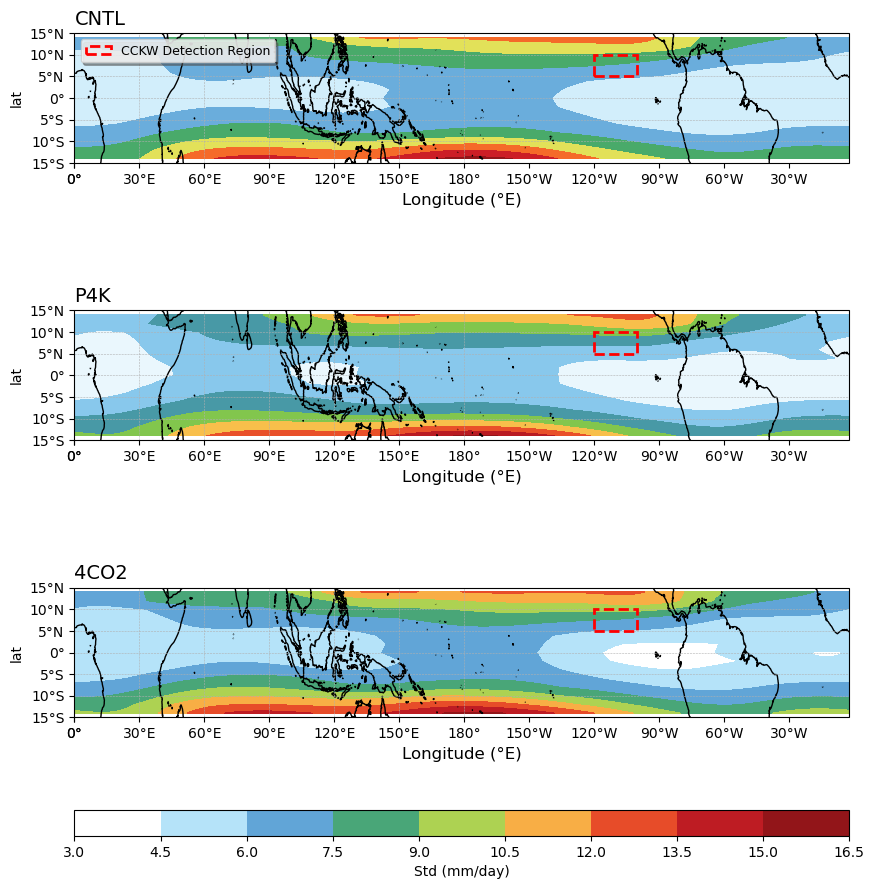

In [30]:

# 正确的 projection
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    nrows=3, ncols=1,
    figsize=(10, 12),
    subplot_kw={'projection': proj}
)

titles = ['CNTL', 'P4K', '4CO2']


lhf_data_dict = {
    'CNTL': lhf_kelvin_cntl,
    'P4K': lhf_kelvin_p4k,
    '4CO2': lhf_kelvin_4co2
}

for ax, key in zip(axes, titles):
    
    data = lhf_data_dict[key].std('time')  # 具有 0–360 经度的 xarray 数据
    
    # 关键：数据需要告诉 cartopy 它本身是 PlateCarree()
    im = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),   # 数据 CRS
        cmap=cmaps.WhiteBlueGreenYellowRed,
        # levels=np.linspace(0, 5, 21),
        add_colorbar=False,

    )
    
    # 海岸线
    ax.coastlines()
    ax.set_aspect(2)
    
    # ========== 新增：绘制TARGET区域矩形框 ==========
    import matplotlib.patches as mpatches
    # TARGET区域: 5°N-10°N, 240°E-260°E
    target_lon_min, target_lon_max = 240, 260
    target_lat_min, target_lat_max = 5, 10
    
    # 创建矩形框
    rect = mpatches.Rectangle(
        (target_lon_min, target_lat_min),  # 左下角坐标
        target_lon_max - target_lon_min,    # 宽度
        target_lat_max - target_lat_min,    # 高度
        linewidth=2,
        edgecolor='red',
        facecolor='none',
        linestyle='--',
        transform=ccrs.PlateCarree(),
        zorder=10,
        label='CCKW Detection Region'
    )
    ax.add_patch(rect)
    
    # 只在第一个子图添加图例
    if key == 'CNTL':
        ax.legend(loc='upper left', fontsize=9, frameon=True, 
                 fancybox=True, shadow=True, framealpha=0.8)
    # =============================================
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    # 经纬度刻度
    xticks = np.arange(0, 361, 30)
    yticks = np.arange(-15, 16, 5)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=False)#True/False
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

    # 网格线
    ax.gridlines(xlocs=xticks, ylocs=yticks, linestyle='--', linewidth=0.4)
    ax.set_title(key, fontsize=14, loc='left')
# 单独 colorbar
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, aspect=30)
cbar.set_label('Std (mm/day)')


plt.show()


In [31]:
all_events['CNTL']['event_dates']

[19,
 29,
 43,
 56,
 63,
 69,
 76,
 81,
 91,
 102,
 113,
 122,
 130,
 135,
 153,
 163,
 169,
 181,
 198,
 212,
 229,
 238,
 244,
 257,
 269,
 279,
 290,
 295,
 305,
 312,
 323,
 333,
 340,
 352,
 357,
 366,
 374,
 379,
 390,
 402,
 415,
 427,
 440,
 448,
 461,
 467,
 477,
 484,
 490,
 495,
 503,
 508,
 519,
 527,
 537,
 547,
 557,
 565,
 572,
 579,
 587,
 599,
 606,
 615,
 620,
 626,
 636,
 643,
 650,
 658,
 664,
 670,
 680,
 690,
 700,
 712,
 723,
 731,
 738,
 748,
 762,
 773,
 780,
 788,
 797,
 813,
 824,
 829,
 841,
 854,
 861,
 870,
 876,
 888,
 900,
 909,
 915,
 920,
 929,
 934,
 941,
 949,
 954,
 960,
 970,
 976,
 986,
 994,
 1002,
 1009,
 1018,
 1029,
 1037,
 1051,
 1066,
 1077,
 1083,
 1089,
 1095,
 1106,
 1111,
 1117,
 1129,
 1135,
 1143,
 1167,
 1178,
 1187,
 1198,
 1205,
 1215,
 1220,
 1231,
 1241,
 1251,
 1258,
 1265,
 1271,
 1283,
 1289,
 1294,
 1303,
 1311,
 1322,
 1333,
 1342,
 1353,
 1364,
 1370,
 1381,
 1389,
 1396,
 1402,
 1411,
 1425,
 1434,
 1443,
 1452,
 1460,
 147

In [32]:
print("\n" + "="*80)
print("STEP 1: Loading filtered precipitation data")
print("="*80)

pr_data_dict = load_filtered_data('pr')


STEP 1: Loading filtered precipitation data

📂 Loading pr data...
  ✅ CNTL: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ P4K: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ 4CO2: Loaded from , Shape=(5114, 15, 180), Size=105.4MB


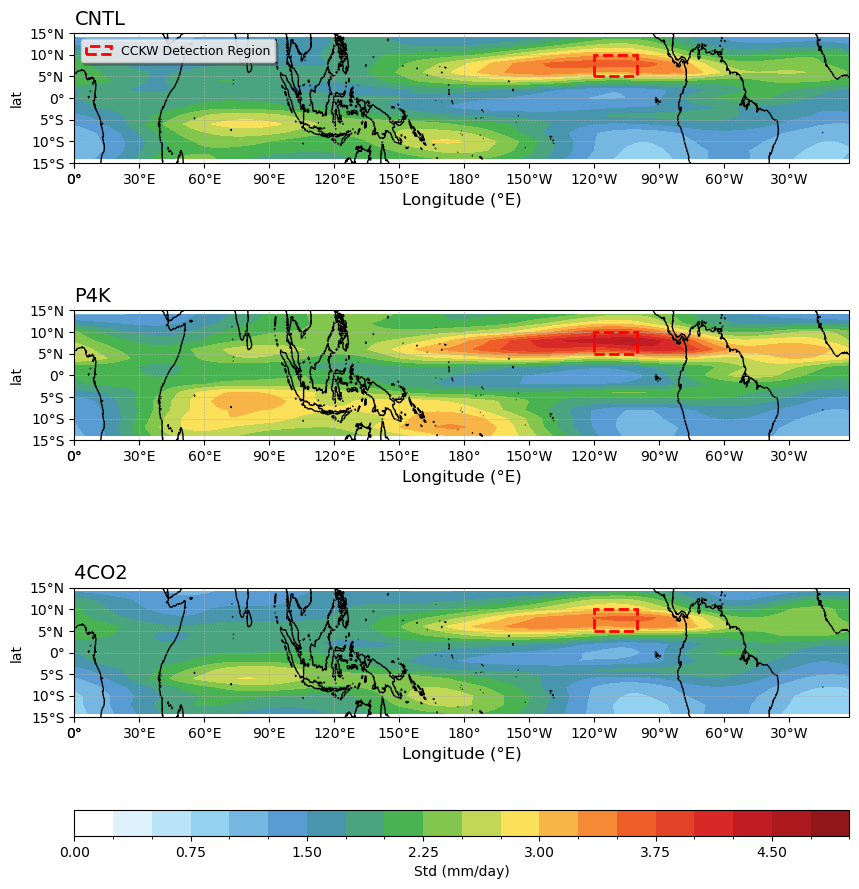

In [33]:

# 正确的 projection
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    nrows=3, ncols=1,
    figsize=(10, 12),
    subplot_kw={'projection': proj}
)

titles = ['CNTL', 'P4K', '4CO2']

for ax, key in zip(axes, titles):
    
    data = pr_data_dict[key].std('time')  # 具有 0–360 经度的 xarray 数据
    
    # 关键：数据需要告诉 cartopy 它本身是 PlateCarree()
    im = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),   # 数据 CRS
        cmap=cmaps.WhiteBlueGreenYellowRed,
        levels=np.linspace(0, 5, 21),
        add_colorbar=False,

    )
    
    # 海岸线
    ax.coastlines()
    ax.set_aspect(2)
    
    # ========== 新增：绘制TARGET区域矩形框 ==========
    import matplotlib.patches as mpatches
    # TARGET区域: 5°N-10°N, 240°E-260°E
    target_lon_min, target_lon_max = 240, 260
    target_lat_min, target_lat_max = 5, 10
    
    # 创建矩形框
    rect = mpatches.Rectangle(
        (target_lon_min, target_lat_min),  # 左下角坐标
        target_lon_max - target_lon_min,    # 宽度
        target_lat_max - target_lat_min,    # 高度
        linewidth=2,
        edgecolor='red',
        facecolor='none',
        linestyle='--',
        transform=ccrs.PlateCarree(),
        zorder=10,
        label='CCKW Detection Region'
    )
    ax.add_patch(rect)
    
    # 只在第一个子图添加图例
    if key == 'CNTL':
        ax.legend(loc='upper left', fontsize=9, frameon=True, 
                 fancybox=True, shadow=True, framealpha=0.8)
    # =============================================
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    # 经纬度刻度
    xticks = np.arange(0, 361, 30)
    yticks = np.arange(-15, 16, 5)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=False)#True/False
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

    # 网格线
    ax.gridlines(xlocs=xticks, ylocs=yticks, linestyle='--', linewidth=0.4)
    ax.set_title(key, fontsize=14, loc='left')
# 单独 colorbar
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, aspect=30)
cbar.set_label('Std (mm/day)')


plt.show()


In [34]:
ua_data_dict = load_filtered_data('ua')
ua_data_dict


📂 Loading ua data...
  ✅ CNTL: Loaded from , Shape=(5114, 22, 15, 180), Size=2317.6MB
  ✅ P4K: Loaded from , Shape=(5114, 22, 15, 180), Size=2317.6MB
  ✅ 4CO2: Loaded from , Shape=(5114, 22, 15, 180), Size=2317.6MB


{'CNTL': <xarray.DataArray (time: 5114, lev: 22, lat: 15, lon: 180)> Size: 2GB
 [303771600 values with dtype=float64]
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lev      (lev) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
   * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
 Attributes:
     long_name:        kelvin
     min_equiv_depth:  8
     max_equiv_depth:  90
     min_wavenumber:   2
     max_wavenumber:   14
     min_period:       3
     max_period:       20
     min_frequency:    0.05
     max_frequency:    0.3333333333333333
     units:            m/s,
 'P4K': <xarray.DataArray (time: 5114, lev: 22, lat: 15, lon: 180)> Size: 2GB
 [303771600 values with dtype=float64]
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lev      (lev) int64 176B 31 35 38 41 46 51

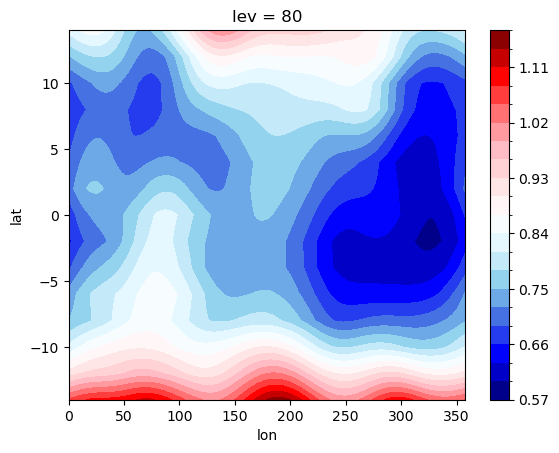

In [35]:
ua_data_dict['CNTL'].sel(lev=80).std('time').plot.contourf(cmap=mycmap,levels=20)

In [36]:
# 步骤3: 使用相同的事件进行合成
lhf_composite_cntl, lhf_std_cntl, n_events_cntl = apply_composite_to_other_variable(
    variable_data=lhf_kelvin_cntl,
    event_dates=all_events['CNTL']['event_dates'],  # 使用相同的事件！
    lags=range(-4, 5),  # 使用相同的lag范围！
    exp_name='CNTL'
)

lhf_composite_p4k, lhf_std_p4k, n_events_p4k = apply_composite_to_other_variable(
    variable_data=lhf_kelvin_p4k,
    event_dates=all_events['P4K']['event_dates'],  # 使用相同的事件！
    lags=range(-4, 5),  # 使用相同的lag范围！
    exp_name='P4K'
)

lhf_composite_4co2, lhf_std_4co2, n_events_4co2 = apply_composite_to_other_variable(
    variable_data=lhf_kelvin_4co2,
    event_dates=all_events['4CO2']['event_dates'],  # 使用相同的事件！
    lags=range(-4, 5),  # 使用相同的lag范围！
    exp_name='4CO2'
)



🔄 Computing composite for CNTL
   Variable shape: (5114, 15, 180)
   Number of events: 546
   Lag range: -4 to 4 days
✅ Composite computed successfully
   Valid events used: 546
   Composite shape: (9, 15, 180)
   Value range: [-2.5109e+00, 2.6217e+00]

🔄 Computing composite for P4K
   Variable shape: (5114, 15, 180)
   Number of events: 548
   Lag range: -4 to 4 days
✅ Composite computed successfully
   Valid events used: 546
   Composite shape: (9, 15, 180)
   Value range: [-2.5109e+00, 2.6217e+00]

🔄 Computing composite for P4K
   Variable shape: (5114, 15, 180)
   Number of events: 548
   Lag range: -4 to 4 days
✅ Composite computed successfully
   Valid events used: 548
   Composite shape: (9, 15, 180)
   Value range: [-2.6089e+00, 2.7497e+00]

🔄 Computing composite for 4CO2
   Variable shape: (5114, 15, 180)
   Number of events: 552
   Lag range: -4 to 4 days
✅ Composite computed successfully
   Valid events used: 548
   Composite shape: (9, 15, 180)
   Value range: [-2.6089e+00


🎨 Plotting improved spatial composite maps...


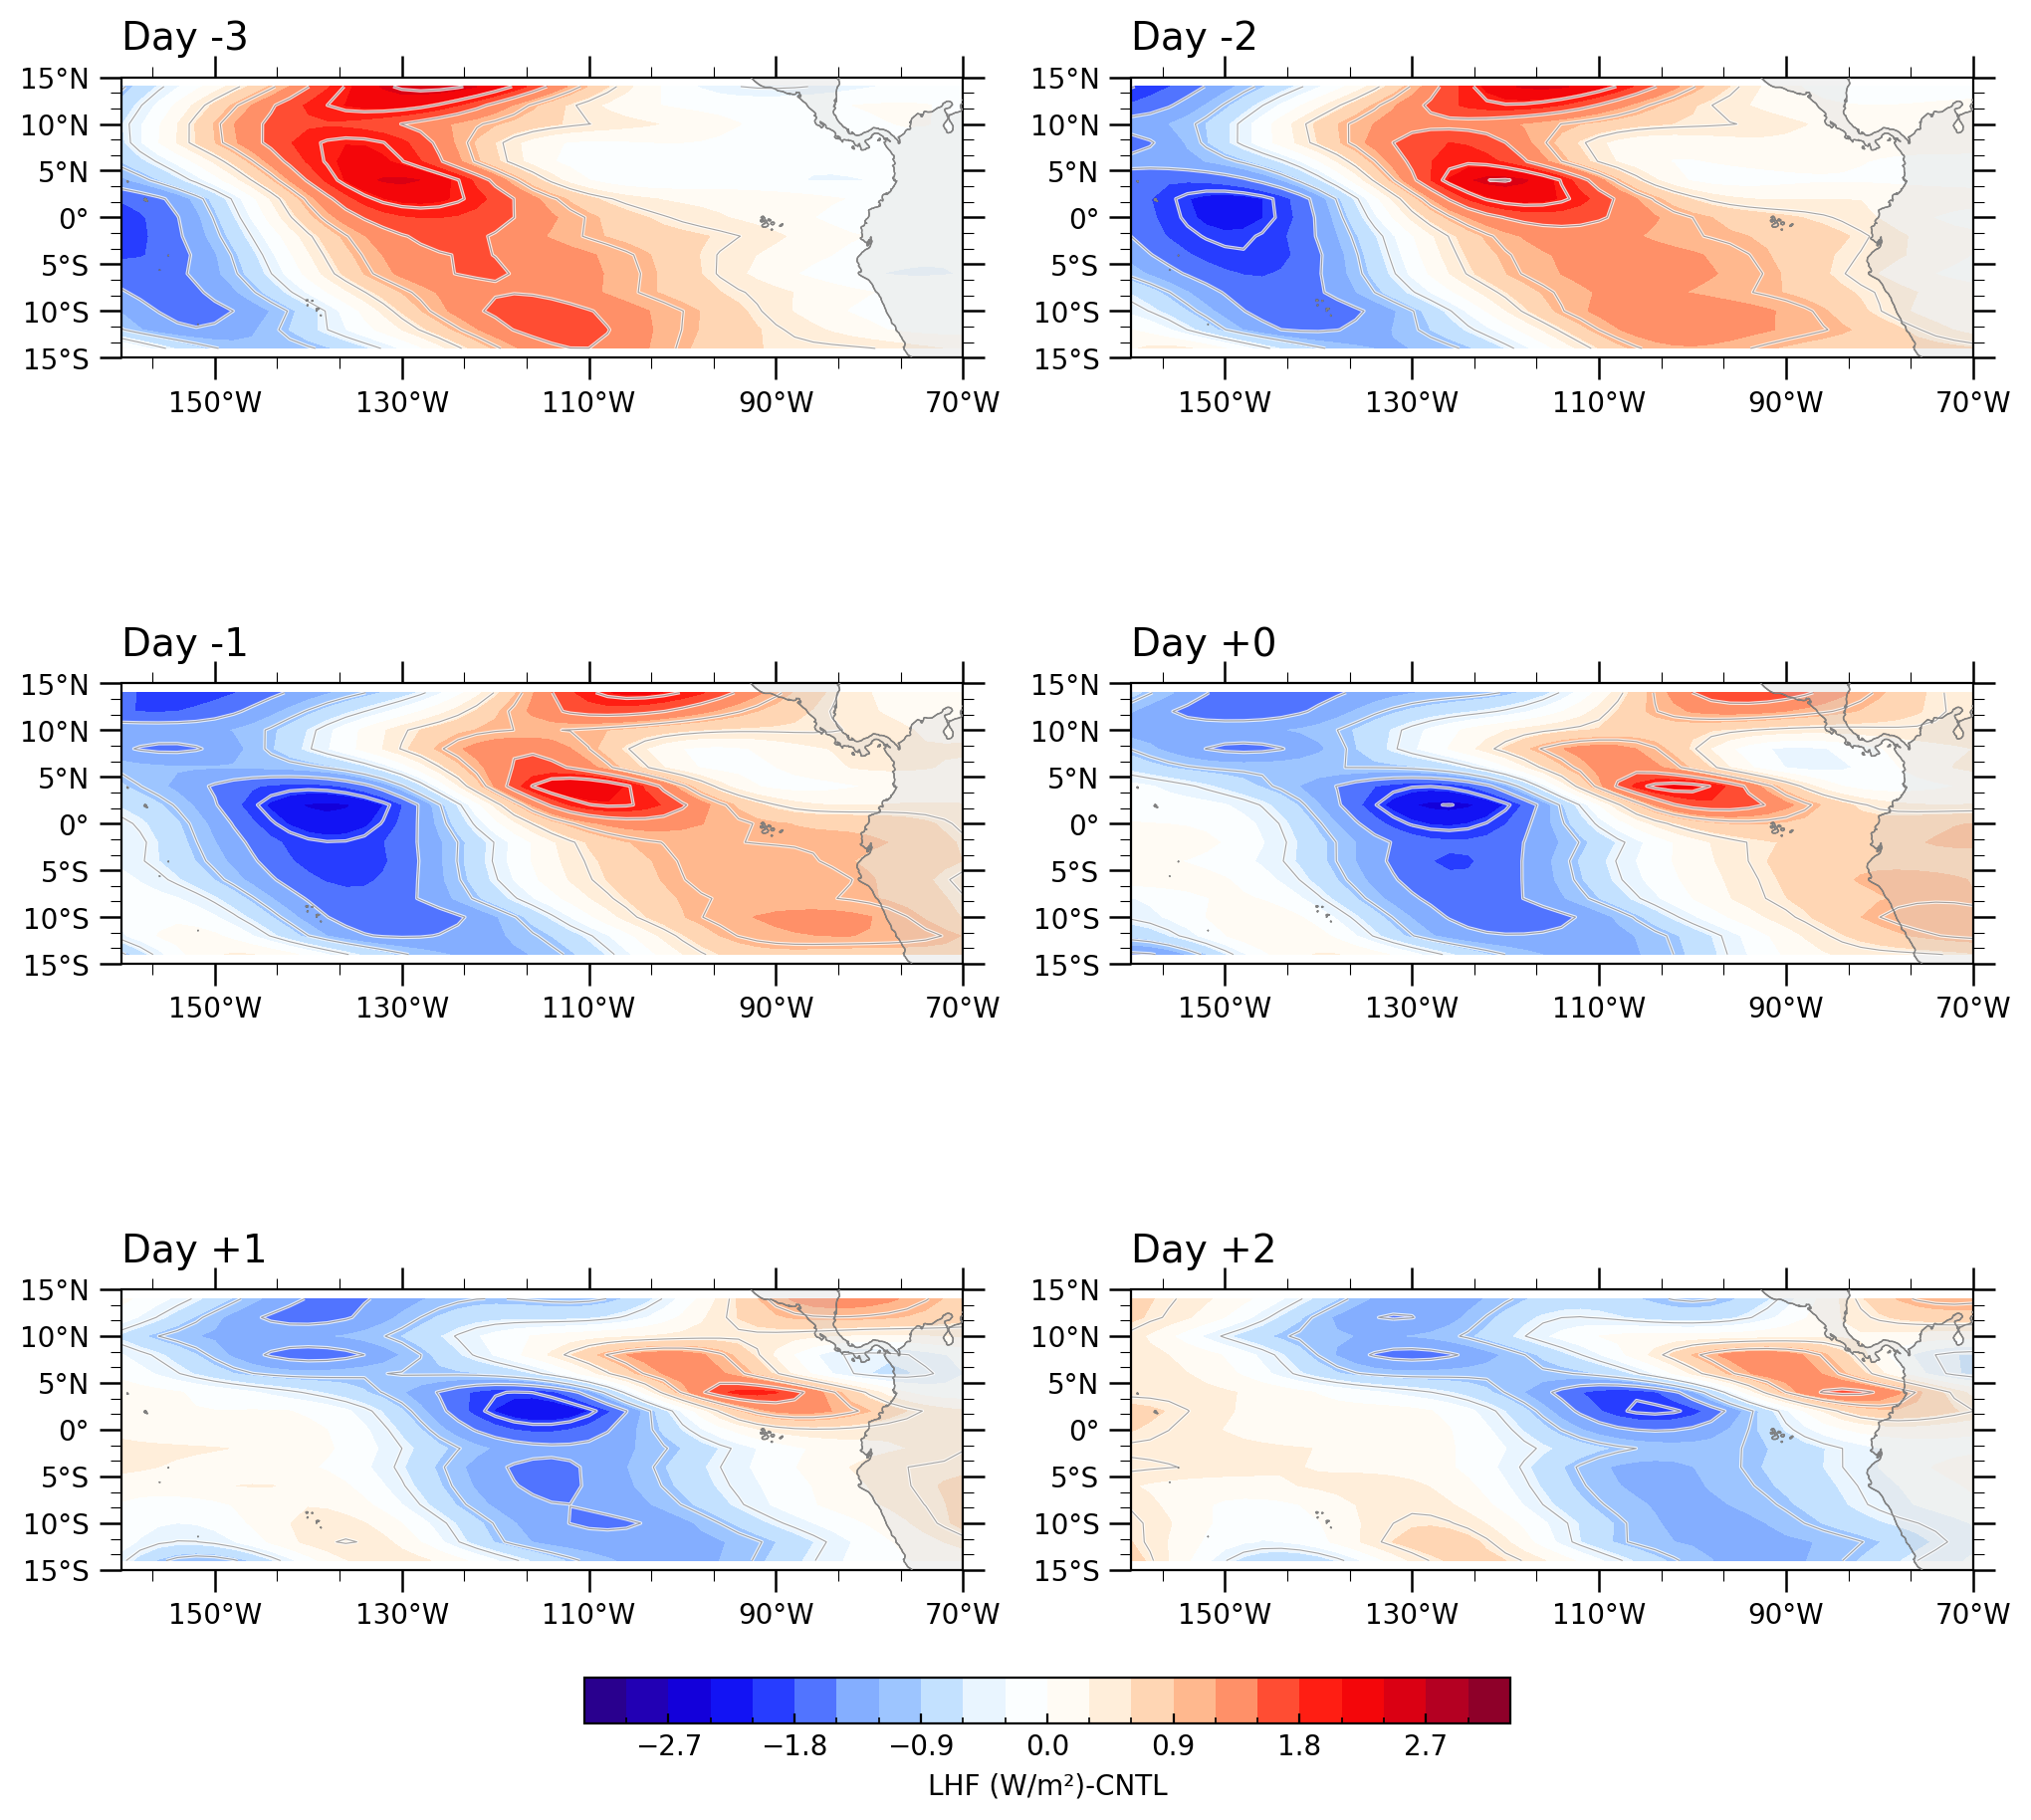

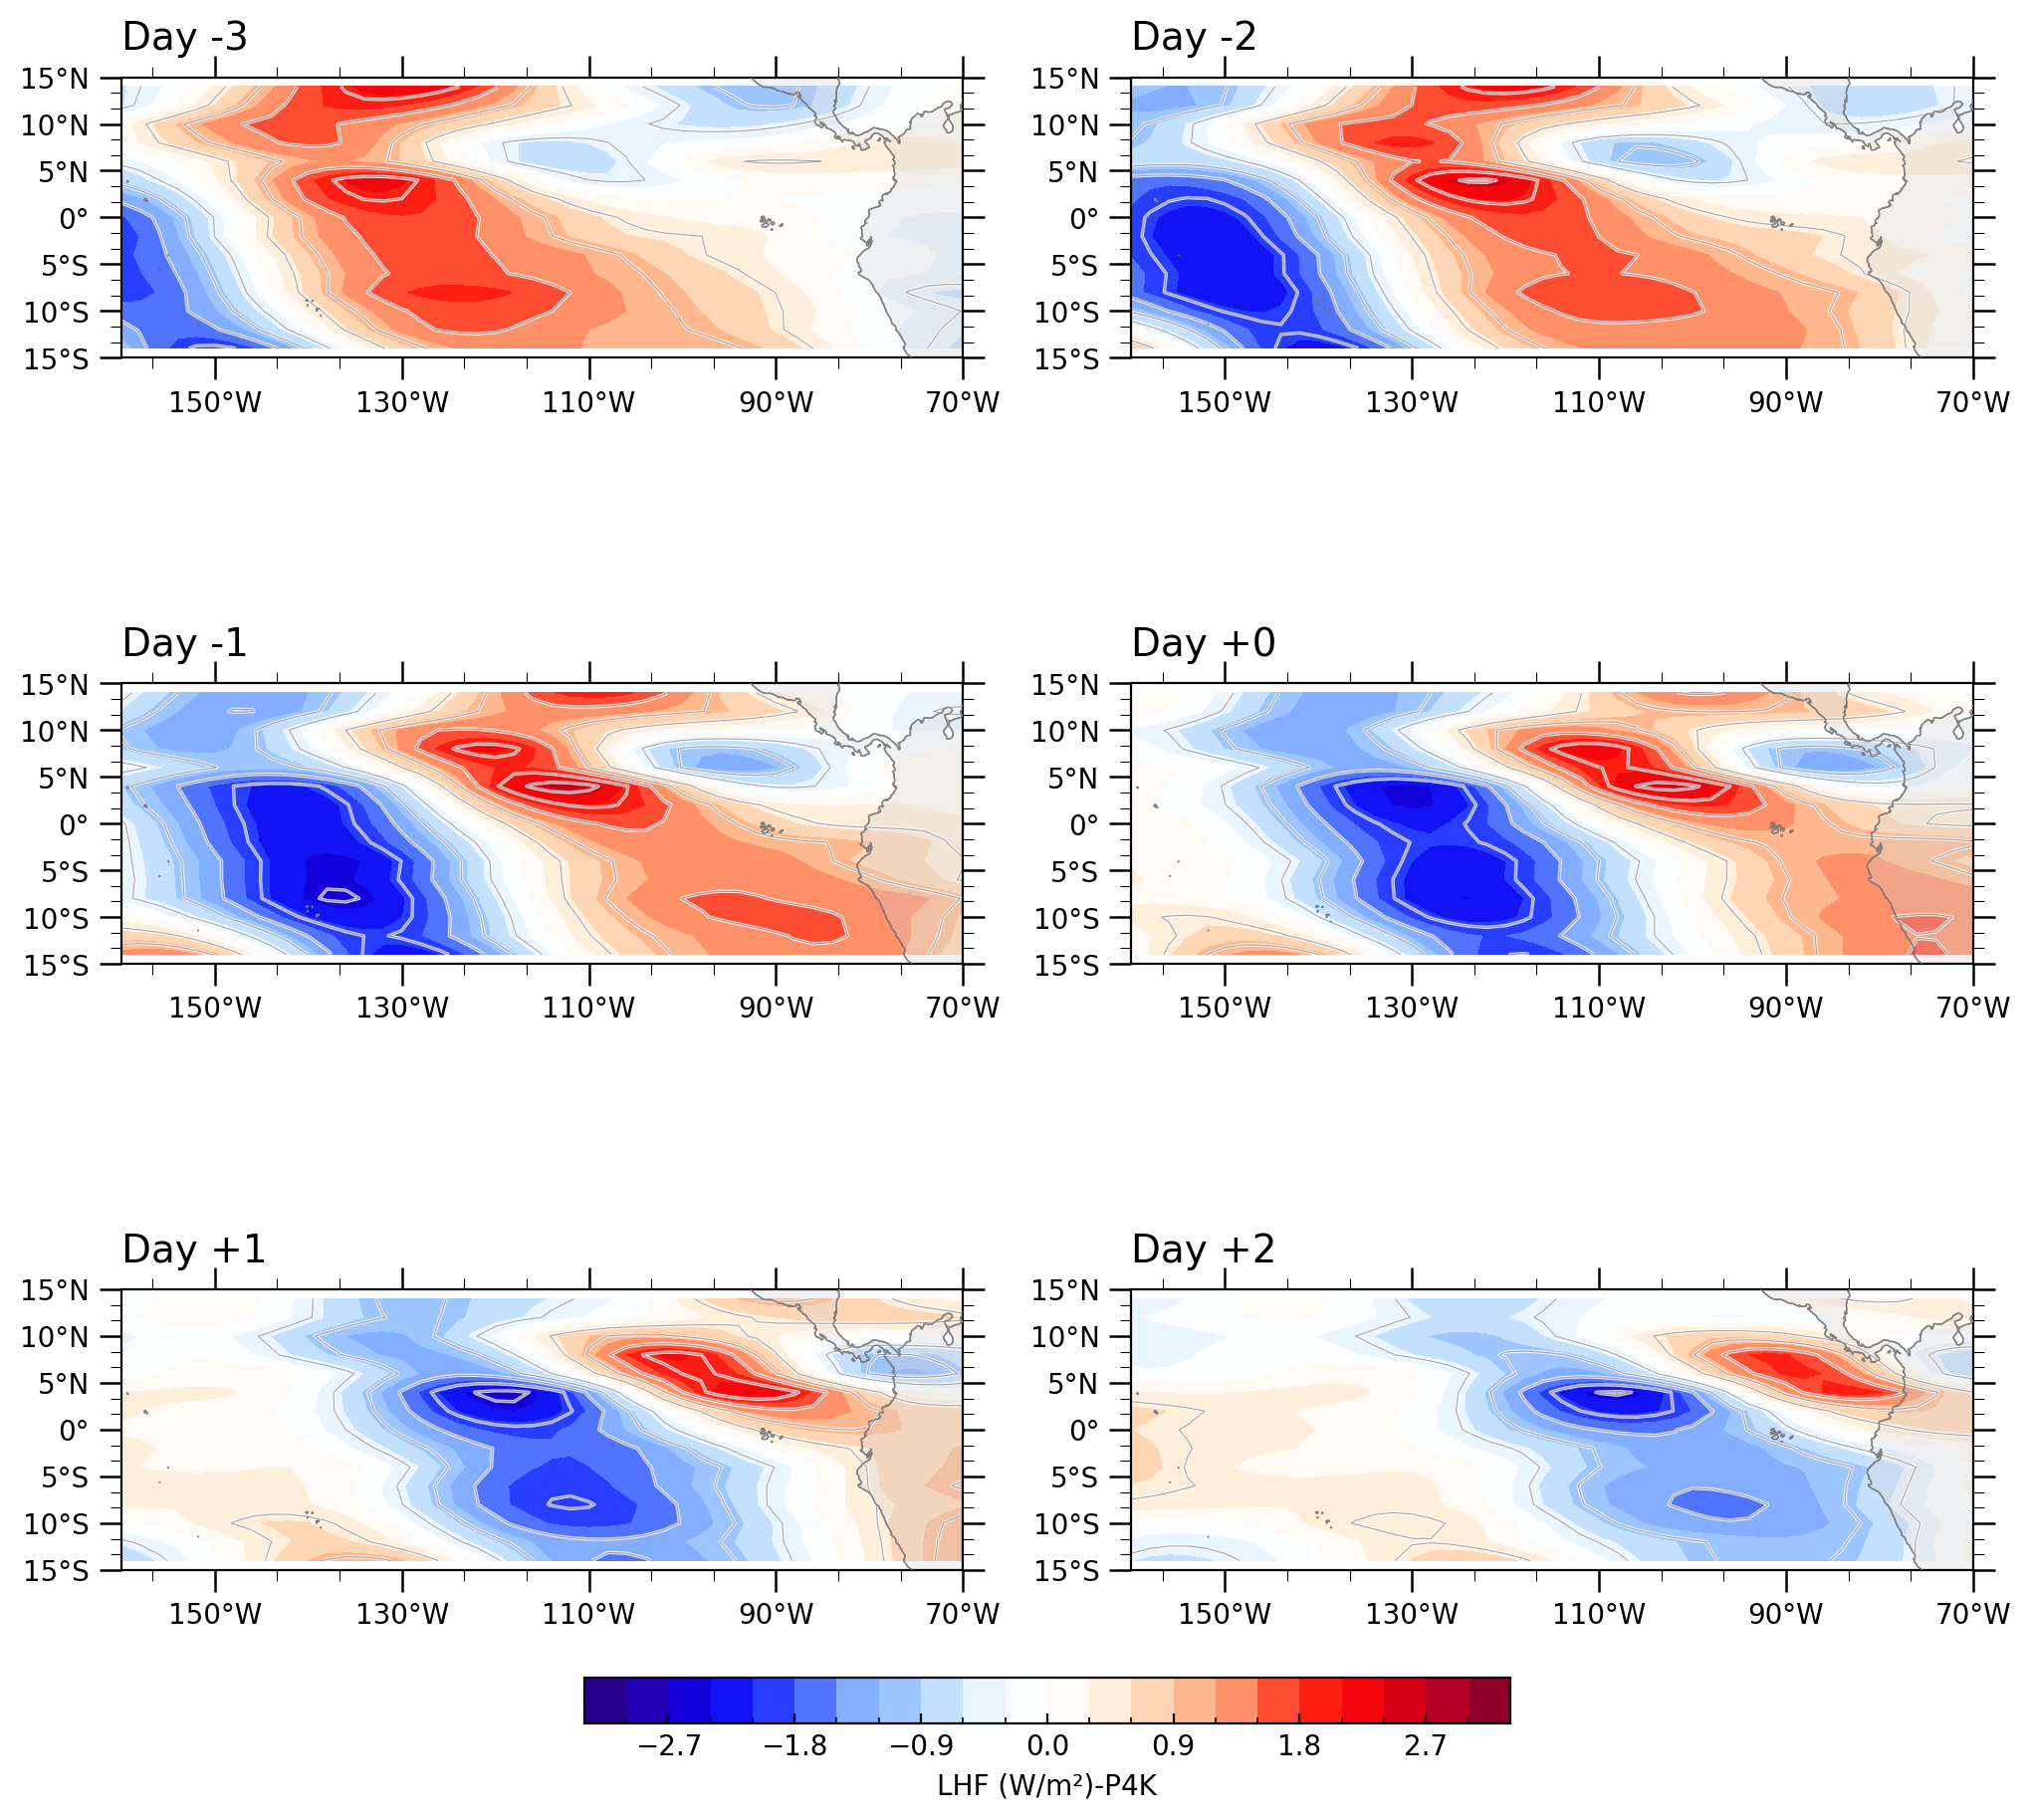

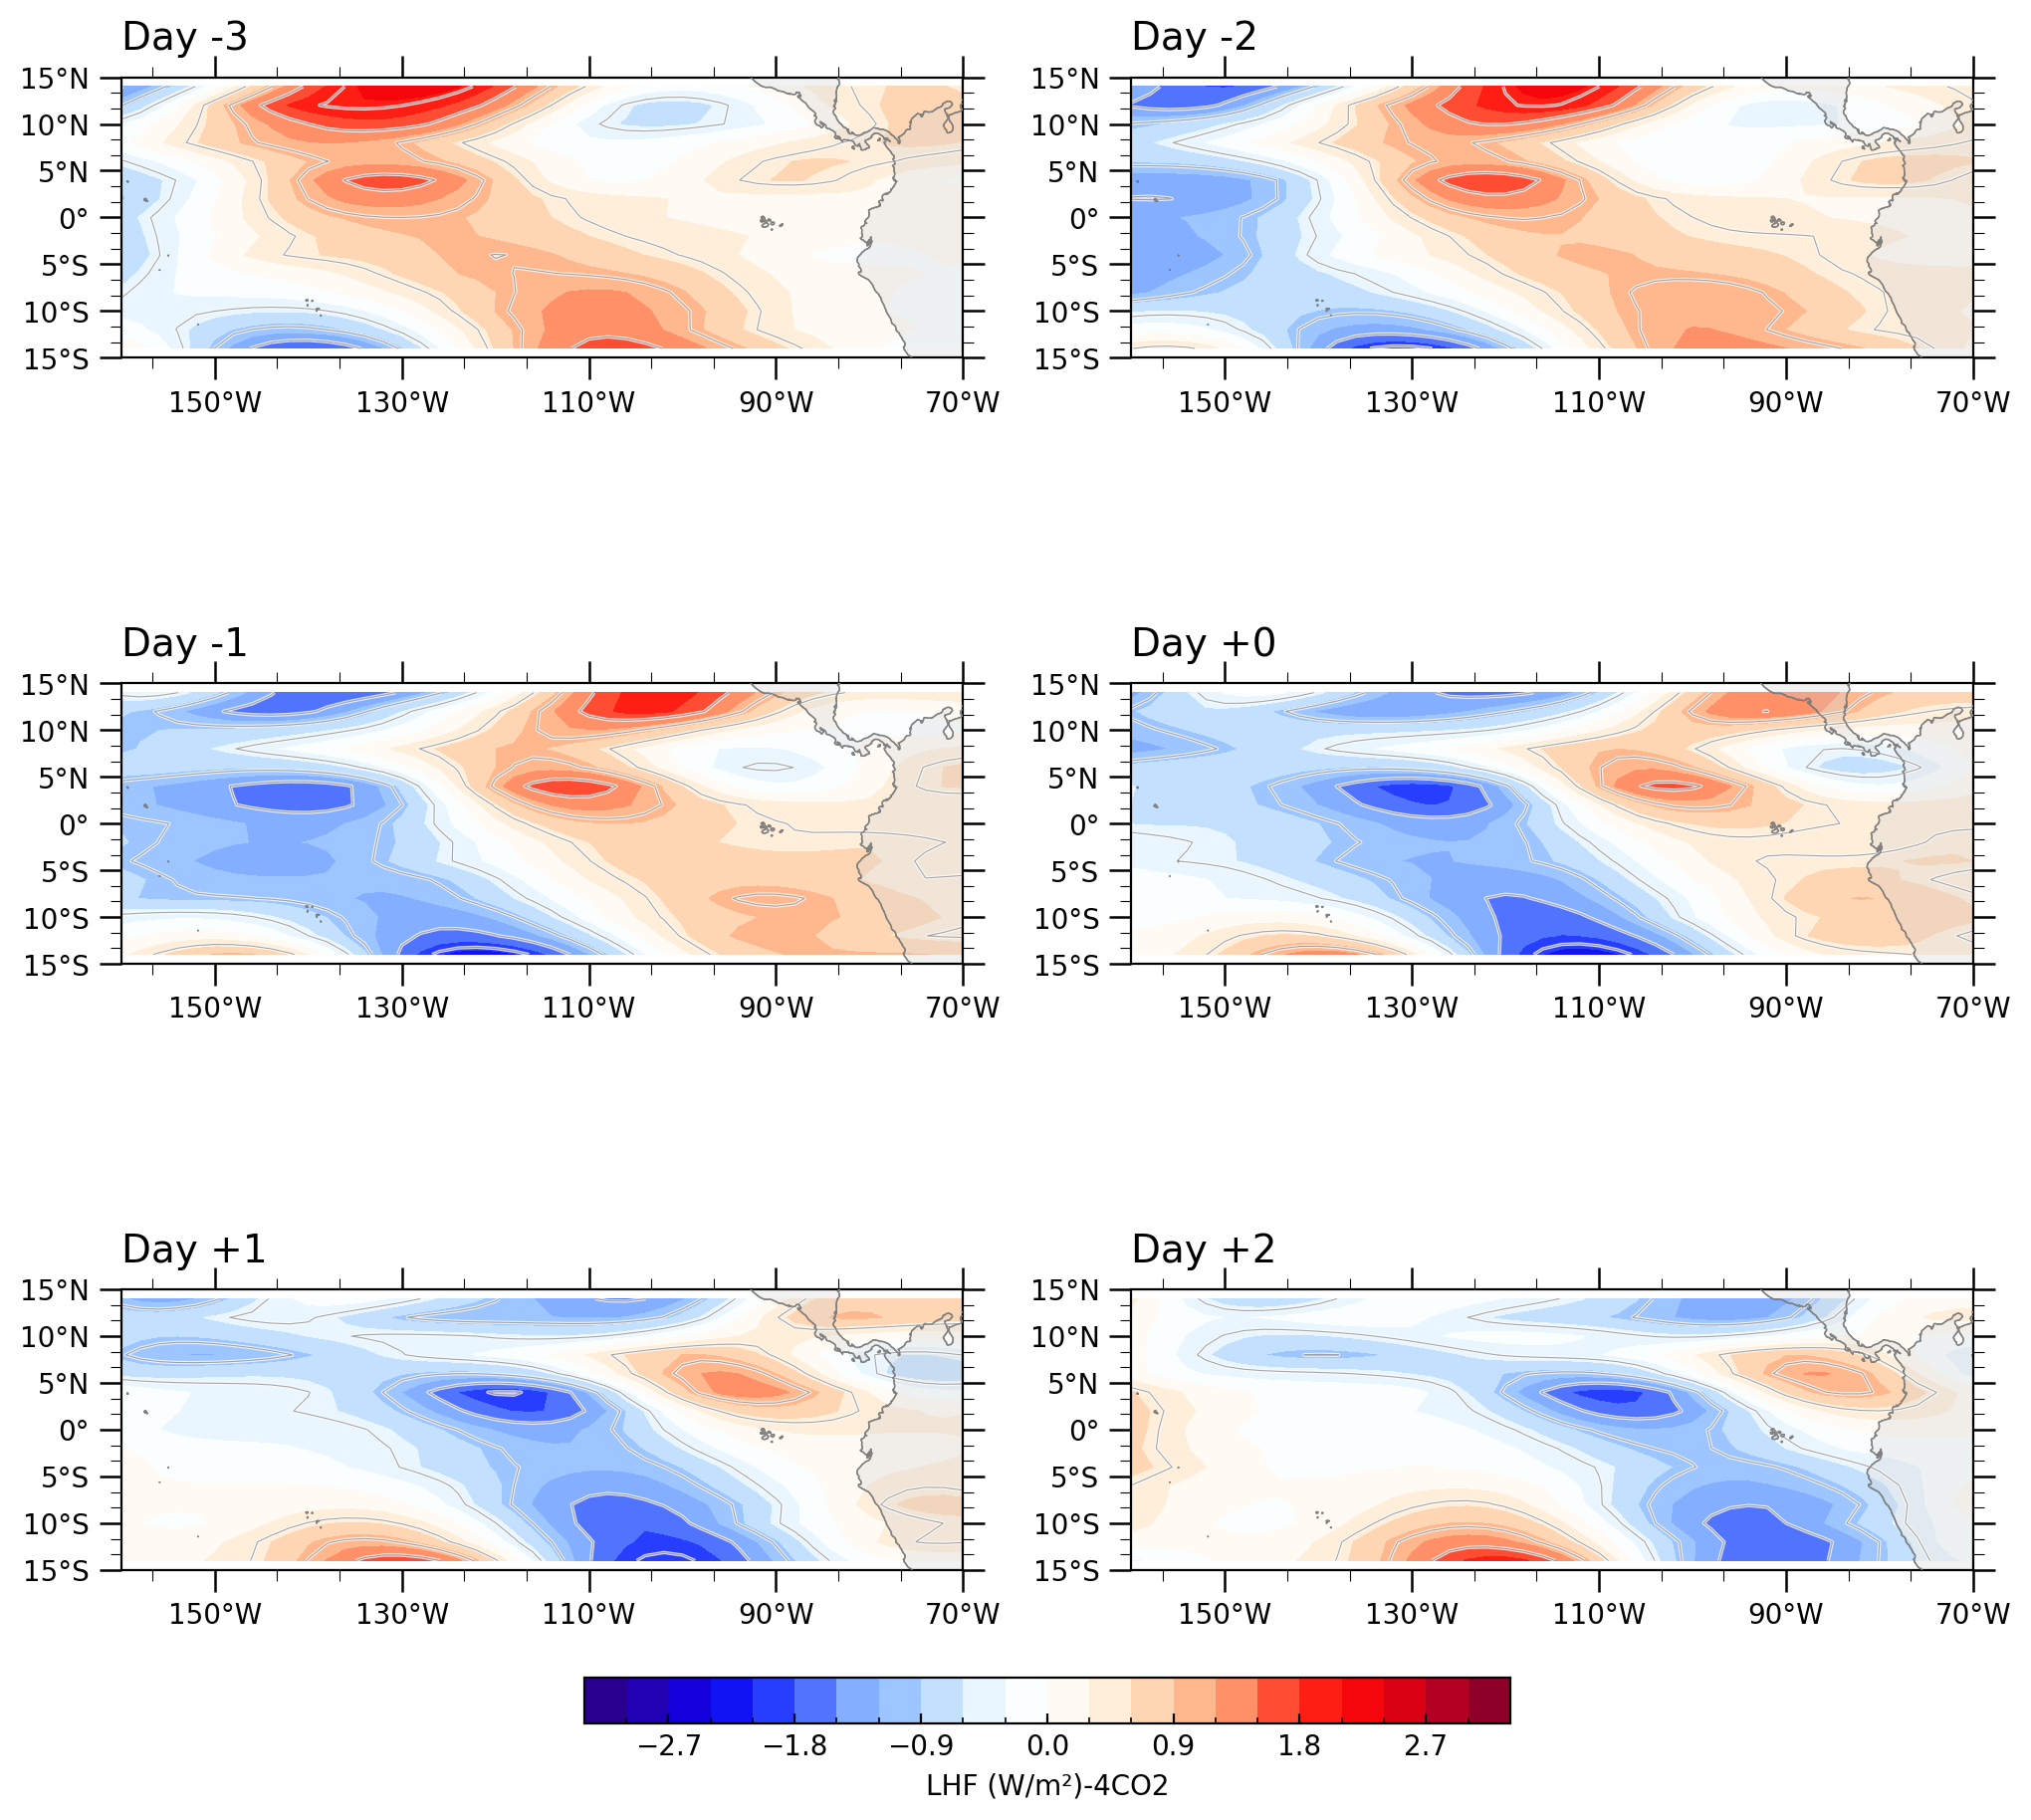

In [37]:
def plot_spatial_composite_3x2(composite, lag_days=[-3, -2, -1, 0, 1, 2],
                              figsize=(12, 14), vmin=-2.0, vmax=2.0, exp=''):
    """
    绘制单实验的空间分布图，固定 3x2 布局
    使用改进的配色方案和样式
    """
    import matplotlib.patheffects as PathEffects
    try:
        import geocat.viz.util as gvutil
        use_geocat = True
    except ImportError:
        print("⚠️  geocat-viz not available, using basic style")
        use_geocat = False

    nrows, ncols = 3, 2
    total_panels = nrows * ncols

    # 使用中心经度210°的投影
    proj = ccrs.PlateCarree(central_longitude=210)
    fig = plt.figure(figsize=figsize, dpi=200)
    
    # 创建自定义colormap（使用连续插值而不是固定颜色列表）
    newcmp = cmaps.NCV_blu_red
    
    from matplotlib.colors import LinearSegmentedColormap
    # 从 NCV_blu_red 创建连续的 colormap
    colors_blue = [newcmp[i].colors for i in [5, 20, 35, 50, 65, 85, 95, 110, 125]]
    colors_red = [newcmp[i].colors for i in [135, 150, 165, 180, 200, 210, 220, 235, 250]]
    
    # 创建颜色节点：蓝色 -> 白色 -> 红色
    # all_colors = colors_blue +  colors_red
    all_colors = colors_blue + [[1., 1., 1.]] + colors_red
    n_colors = len(all_colors)
    color_positions = np.linspace(0, 1, n_colors)
    
    # 创建连续的 colormap
    custom_cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', 
                                                     list(zip(color_positions, all_colors)),
                                                     N=256)
    
    # 设置填色图参数（增加层级数使颜色过渡更平滑）
    levels_fill = np.linspace(vmin, vmax, 51)  # 从21增加到51
    
    # 设置等值线参数（更细更柔和）
    delc = 0.5
    levels_contour = np.arange(-10, 0, delc)
    levels_contour = np.append(levels_contour, np.arange(delc, 10, delc))
    
    ax_list = []
    
    for idx in range(total_panels):
        ax = fig.add_subplot(nrows, ncols, idx + 1, projection=proj)
        ax_list.append(ax)
        
        if idx < len(lag_days):
            lag = lag_days[idx]
            data_lag = composite.sel(lag=lag)
            
            # 添加循环经度以避免间隙
            if use_geocat:
                data_lag = gvutil.xr_add_cyclic_longitudes(data_lag, 'lon')
            
            # 添加海岸线
            ax.coastlines(linewidth=0.5, alpha=0.6)
            
            # 设置坐标范围和刻度 (150°E - 250°E)
            # 由于 central_longitude=210, 150°E对应-60°, 250°E对应+40°
            if use_geocat:
                gvutil.set_axes_limits_and_ticks(ax,
                                               xlim=(-10, 80),
                                               ylim=(-15, 15),
                                               xticks=np.arange(-40, 91, 20),
                                               yticks=np.arange(-15, 16, 5))
                gvutil.add_major_minor_ticks(ax, labelsize=10)
                gvutil.add_lat_lon_ticklabels(ax)
            else:
                ax.set_xlim([-60, 40])
                ax.set_ylim([-15, 15])
                ax.set_xticks(np.arange(-60, 41, 20))
                ax.set_yticks(np.arange(-15, 16, 5))
                ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
                ax.yaxis.set_major_formatter(LatitudeFormatter())
            
            # 绘制填色图
            cf = data_lag.plot.contourf(
                ax=ax,
                levels=np.linspace(vmin, vmax, 21),  # 使用更多层级
                cmap=custom_cmap,  # 使用连续的 colormap
                add_colorbar=False,
                transform=ccrs.PlateCarree(),
                extend='both',
                add_labels=False 
            )
            
            # 添加陆地和海岸线
            ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2, alpha=0.3)
            ax.add_feature(cfeature.COASTLINE, edgecolor='gray', linewidth=0.5, zorder=3)
            
            # 绘制等值线（更细更柔和的样式）
            contour = data_lag.plot.contour(
                ax=ax,
                levels=levels_contour,
                colors='dimgray',  # 使用更柔和的灰色
                alpha=0.6,  # 降低透明度使其更柔和
                linewidths=0.4,  # 稍微增加线宽但保持细腻
                linestyles='solid',
                add_labels=False,
                transform=ccrs.PlateCarree()
            )
            
            # 添加柔和的白色边缘效果
            try:
                pe = [PathEffects.withStroke(linewidth=1.2, foreground="white", alpha=0.8)]
                if hasattr(contour, 'collections'):
                    for collection in contour.collections:
                        collection.set_path_effects(pe)
                else:
                    # xarray返回的contour对象本身就是collection
                    plt.setp(contour.collections if hasattr(contour, 'collections') else [contour], 
                            path_effects=pe)
            except:
                pass  # 如果设置失败，继续
            
            # 设置标题
            if use_geocat:
                gvutil.set_titles_and_labels(ax,
                                           lefttitle=f'Day {lag:+d}',
                                           lefttitlefontsize=14,
                                           righttitle='',
                                           xlabel="",
                                           ylabel="")
            else:
                ax.set_title(f'Day {lag:+d}', fontsize=14, loc='left')
        
        else:
            # 空白面板
            ax.axis("off")
    
    # 添加颜色棒（更平滑，不显示边缘线）
    cbar = fig.colorbar(cf, ax=ax_list,
                 drawedges=False,  # 去掉边缘线使colorbar更平滑
                 orientation='horizontal',
                 shrink=0.5,
                 pad=0.05,
                 extendfrac='auto',
                 extendrect=True,
                 label='LHF (W/m²)'+ exp)
    
    cbar.ax.tick_params(labelsize=10,direction='in',which='both',)
    
    
    # save_path = os.path.join(FIG_SAVE_DIR, "composite_spatial_maps_3x2_improved.png")
    # plt.savefig(save_path, dpi=200, bbox_inches='tight')
    # print(f"💾 Figure saved: {save_path}")

    return fig

# 绘制改进样式的空间分布图
print("\n🎨 Plotting improved spatial composite maps...")
fig_spatial = plot_spatial_composite_3x2(
    lhf_composite_cntl,   # 单个实验
    lag_days=[-3, -2, -1, 0, 1, 2],
    vmin=-3,
    vmax=3,
    exp='-CNTL'
)

fig_spatial_p4k = plot_spatial_composite_3x2(
    lhf_composite_p4k,   # 单个实验
    lag_days=[-3, -2, -1, 0, 1, 2],
    vmin=-3,
    vmax=3,
    exp='-P4K'
)

fig_spatial_4co2 = plot_spatial_composite_3x2(
    lhf_composite_4co2,   # 单个实验
    lag_days=[-3, -2, -1, 0, 1, 2],
    vmin=-3,
    vmax=3,
    exp='-4CO2'
)
plt.show()



In [42]:
# ============================================================================
# 函数：绘制经度剖面曲线（类似Fig. 4）
# ============================================================================

def plot_longitude_profile_curves(composite_data, var_name='Precipitation',
                                  lag_days=[-4, -2, 0, 2, 4],
                                  lat_avg=slice(5, 10),
                                  lon_range=(170, 290),
                                  ylabel='mm/day',
                                  add_mean=True,
                                  figsize=(10, 5),
                                  colors=None,
                                  linestyles=None):
    """
    绘制单个实验的经度剖面曲线图
    
    Parameters:
    -----------
    composite_data : xr.DataArray
        合成数据，维度为 (lag, lat, lon)
    var_name : str
        变量名称
    lag_days : list
        要绘制的lag天数
    lat_avg : slice
        纬度平均范围
    lon_range : tuple
        经度范围（度E）
    ylabel : str
        Y轴标签
    add_mean : bool
        是否添加气候态平均值曲线
    figsize : tuple
        图像大小
    colors : list, optional
        曲线颜色列表
    linestyles : list, optional
        曲线样式列表
    
    Returns:
    --------
    fig, ax : matplotlib对象
    """
    
    # 纬度平均
    data_lat_avg = composite_data.sel(lat=lat_avg).mean('lat')
    
    # 经度范围
    lons = data_lat_avg.lon.values
    lon_mask = (lons >= lon_range[0]) & (lons <= lon_range[1])
    data_lon_sel = data_lat_avg.isel(lon=lon_mask)
    lons_sel = lons[lon_mask]
    
    # 默认颜色和线型
    if colors is None:
        colors = plt.cm.RdBu_r(np.linspace(0.1, 0.9, len(lag_days)))
    if linestyles is None:
        linestyles = ['-'] * len(lag_days)
    
    # 绘图
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # 绘制不同lag的曲线
    for i, lag in enumerate(lag_days):
        data_lag = data_lon_sel.sel(lag=lag)
        label = f'Day {lag:+d}' if lag != 0 else 'Day 0 (Peak)'
        ax.plot(lons_sel, data_lag.values, 
               color=colors[i], linestyle=linestyles[i],
               linewidth=2, label=label, alpha=0.8)
    
    # 添加气候态平均（如果需要）
    if add_mean:
        mean_value = data_lon_sel.mean(dim=['lag']).values
        ax.axhline(y=mean_value.mean(), color='gray', 
                  linestyle='--', linewidth=1.5, alpha=0.5,
                  label='Mean')
    
    # 零线
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
    
    # 设置
    ax.set_xlabel('Longitude (°E)', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(var_name, fontsize=13, fontweight='bold', loc='left')
    ax.set_xlim(lon_range)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='best', fontsize=9, ncol=2, frameon=True, 
             fancybox=True, shadow=True)
    
    plt.tight_layout()
    
    return fig, ax


print("✅ Longitude profile curve plotting function defined")

✅ Longitude profile curve plotting function defined


In [40]:
# ============================================================================
# 准备数据：确保所有composite数据已加载
# ============================================================================

print("\n" + "="*80)
print("📊 Preparing Data for Hovmöller Diagrams")
print("="*80)

# 检查降水composite是否已存在
try:
    test_pr = pr_composite_dict['CNTL']
    print("✅ Precipitation composites already loaded")
except:
    print("⚠️  Loading precipitation composites...")
    pr_composite_dict = {}
    for exp in ['CNTL', 'P4K', '4CO2']:
        composite_file = f'./composite_data/pr_composite_mean_{exp.lower()}.nc'
        if os.path.exists(composite_file):
            pr_composite_dict[exp] = xr.open_dataarray(composite_file)
            print(f"   ✅ {exp} loaded")
        else:
            print(f"   ❌ {exp} not found, computing...")
            pr_composite, _, _ = apply_composite_to_other_variable(
                pr_data_dict[exp], all_events[exp]['event_dates'],
                range(-4, 5), exp_name=exp, verbose=False
            )
            pr_composite_dict[exp] = pr_composite
            pr_composite.to_netcdf(composite_file)

# 检查潜热通量composite
try:
    test_lhf = lhf_composite_cntl
    lhf_composite_dict = {
        'CNTL': lhf_composite_cntl,
        'P4K': lhf_composite_p4k,
        '4CO2': lhf_composite_4co2
    }
    print("✅ Latent heat flux composites already loaded")
except:
    print("⚠️  Latent heat flux composites not found, please run previous cells first!")

# 检查纬向风composite
try:
    test_ua = ua_data_dict['CNTL']
    print("✅ Zonal wind data loaded, computing composites...")
    ua_composite_dict = {}
    for exp in ['CNTL', 'P4K', '4CO2']:
        ua_composite, _, _ = apply_composite_to_other_variable(
            ua_data_dict[exp],
            all_events[exp]['event_dates'],
            range(-4, 5),
            exp_name=exp,
            verbose=False
        )
        ua_composite_dict[exp] = ua_composite
        print(f"   ✅ {exp} composite computed")
except:
    print("⚠️  Zonal wind data not loaded, please run: ua_data_dict = load_filtered_data('ua')")

print("\n✅ Data preparation complete!")


📊 Preparing Data for Hovmöller Diagrams
⚠️  Loading precipitation composites...
   ✅ CNTL loaded
   ✅ P4K loaded
   ✅ 4CO2 loaded
✅ Latent heat flux composites already loaded
✅ Zonal wind data loaded, computing composites...
   ✅ 4CO2 loaded
✅ Latent heat flux composites already loaded
✅ Zonal wind data loaded, computing composites...
   ✅ CNTL composite computed
   ✅ CNTL composite computed
   ✅ P4K composite computed
   ✅ P4K composite computed
   ✅ 4CO2 composite computed

✅ Data preparation complete!
   ✅ 4CO2 composite computed

✅ Data preparation complete!



🎨 Creating Longitude Profile Curves (Similar to Fig. 4)

📍 Analysis Parameters:
   Latitude Averaging: 5-10°N
   Longitude Range: 170°E - 290°E
   Lag Days: -4, -2, 0, +2, +4
   Zonal Wind Level: 80
✅ 3-experiment longitude profile comparison function defined

🎨 Plotting Longitude Profile Curves
💾 Saved: ./figures/latent_heat_flux_composite/longitude_profiles_3exp_3var.png
✅ Longitude profile curves completed!
💾 Saved: ./figures/latent_heat_flux_composite/longitude_profiles_3exp_3var.png
✅ Longitude profile curves completed!


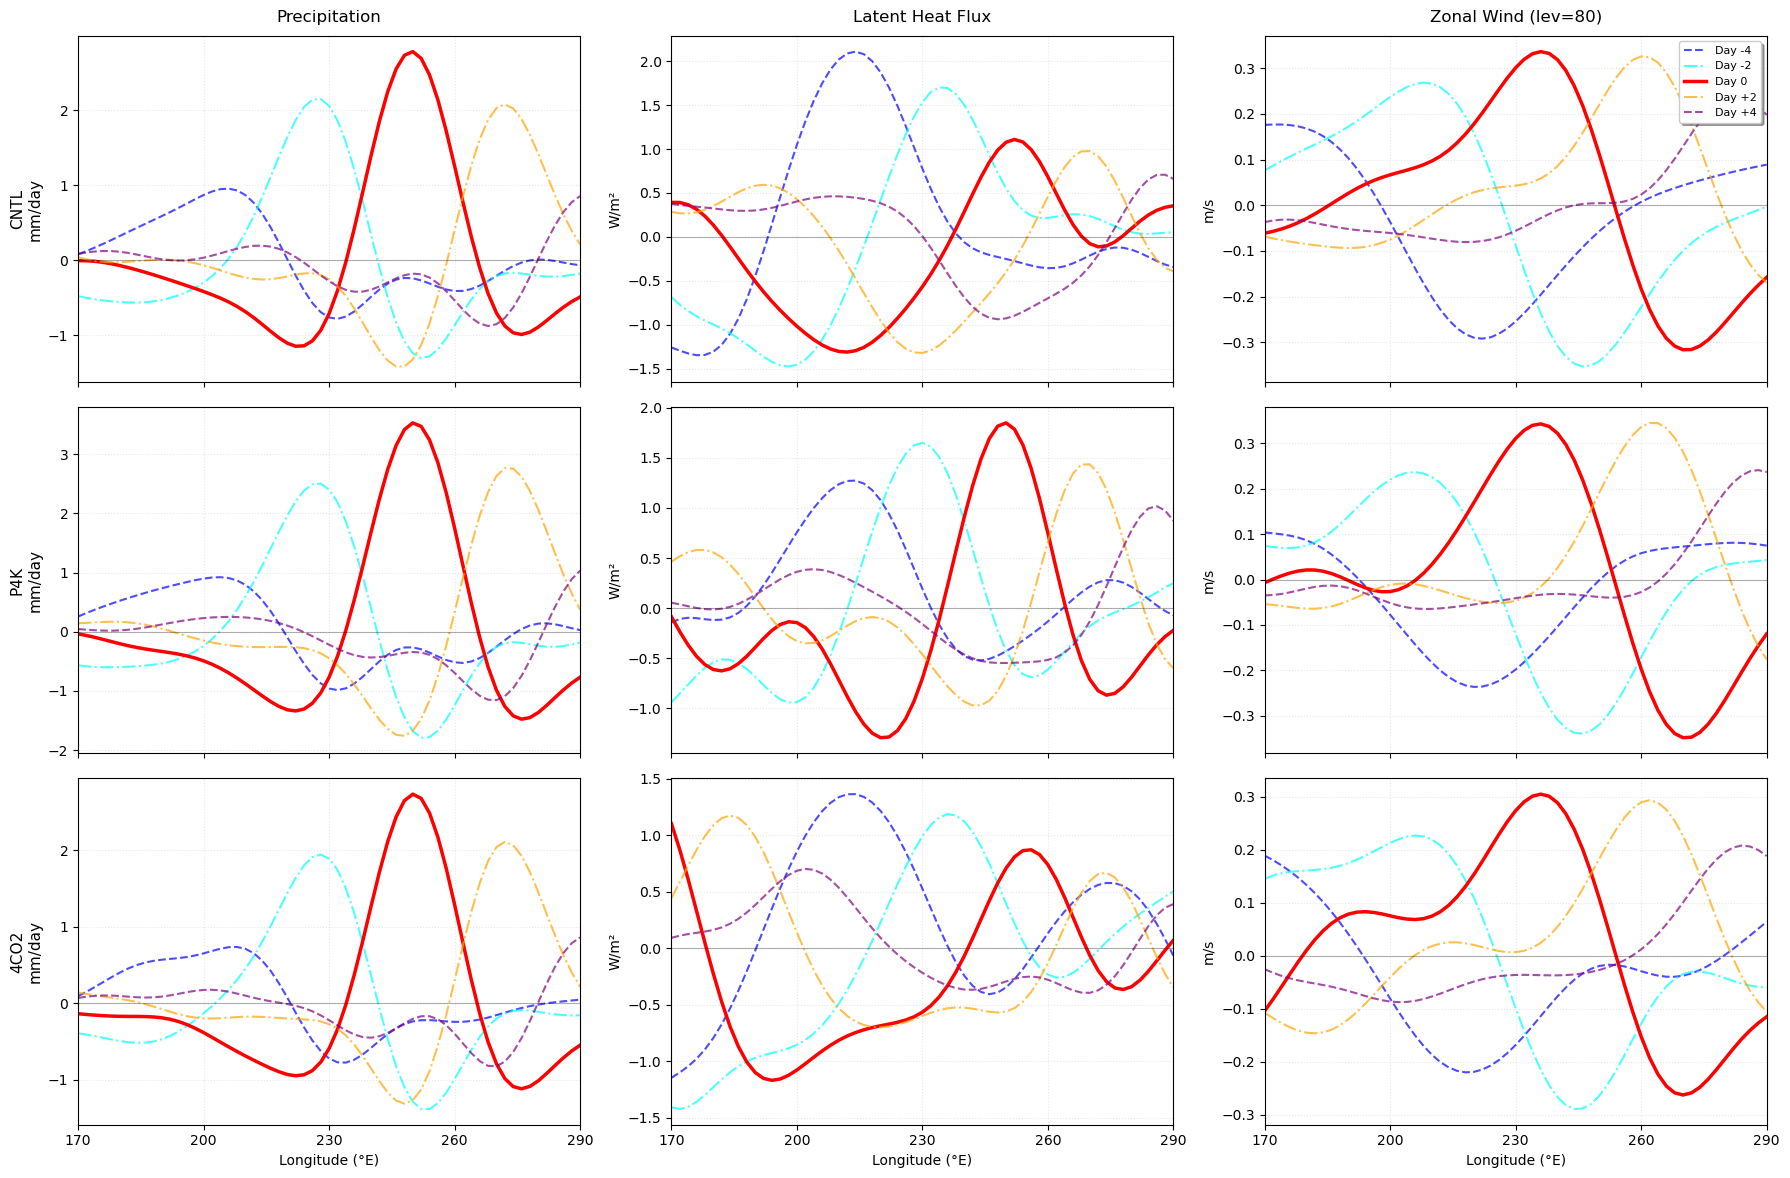


✅ Longitude profile curves completed!

📖 图像解读：
   • 每行：一个实验（CNTL, P4K, 4CO2）
   • 每列：一个变量（降水, 潜热通量, 纬向风）
   • 曲线颜色：
     - 蓝色虚线：Day -4（事件前4天）
     - 青色点划线：Day -2（事件前2天）
     - 红色实线：Day 0（峰值时刻）★
     - 橙色点划线：Day +2（事件后2天）
     - 紫色虚线：Day +4（事件后4天）

🌊 Kelvin波传播特征：
   1. 观察Day -4 → Day 0 → Day +4：峰值位置向西移动
   2. Day 0（红色实线）：在参考区域达到最大值
   3. 对比三个实验：观察振幅和空间结构的差异


In [46]:
# ============================================================================
# 绘制经度剖面曲线图：每个实验单独一个图（1行3列：降水、潜热、风场）
# ============================================================================

print("\n" + "="*80)
print("🎨 Creating Longitude Profile Curves (Similar to Fig. 4)")
print("="*80)
print(f"\n📍 Analysis Parameters:")
print(f"   Latitude Averaging: {5}-{10}°N")
print(f"   Longitude Range: 170°E - 290°E")
print(f"   Lag Days: -4, -2, 0, +2, +4")
print(f"   Zonal Wind Level: 80")
print("="*80)
# ============================================================================
# 函数：绘制单个实验的经度剖面图（1行3列布局）
# ============================================================================

def plot_single_exp_longitude_profiles(pr_composite, lhf_composite, ua_composite,
                                       exp_name='CNTL',
                                       lag_days=[-4, -2, 0, 2, 4],
                                       lat_avg=slice(5, 10),
                                       lon_range=(170, 290),
                                       lev=80,
                                       figsize=(18, 5),
                                       save_path=None):
    """
    绘制单个实验的经度剖面图
    
    布局：1行3列
    - 第1列：降水
    - 第2列：潜热通量
    - 第3列：纬向风
    每列显示该实验不同lag天数的曲线
    
    Parameters:
    -----------
    pr_composite : xr.DataArray
        降水合成数据
    lhf_composite : xr.DataArray
        潜热通量合成数据  
    ua_composite : xr.DataArray
        纬向风合成数据
    exp_name : str
        实验名称
    lag_days : list
        要绘制的lag天数
    lat_avg : slice
        纬度平均范围
    lon_range : tuple
        经度范围
    lev : int
        纬向风的层次
    figsize : tuple
        图像大小
    save_path : str, optional
        保存路径
    
    Returns:
    --------
    fig, axes : matplotlib对象
    """
    
    var_configs = [
        {'data': pr_composite, 'name': 'Precipitation', 'unit': 'mm/day', 'level': None},
        {'data': lhf_composite, 'name': 'Latent Heat Flux', 'unit': 'W/m²', 'level': None},
        {'data': ua_composite, 'name': f'Zonal Wind (lev={lev})', 'unit': 'm/s', 'level': lev}
    ]
    
    panel_labels = ['(a)', '(b)', '(c)']
    
    # 颜色方案：从冷色到暖色，Day 0 使用醒目颜色
    colors_map = {
        -4: 'blue',
        -2: 'cyan', 
        0: 'red',      # Day 0 峰值用红色
        2: 'orange',
        4: 'purple'
    }
    colors = [colors_map.get(lag, 'gray') for lag in lag_days]
    
    linestyles_map = {
        -4: '--',
        -2: '-.',
        0: '-',        # Day 0 用实线
        2: '-.',
        4: '--'
    }
    linestyles = [linestyles_map.get(lag, '-') for lag in lag_days]
    
    # 创建图形
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    for col_idx, var_config in enumerate(var_configs):
        ax = axes[col_idx]
        
        # 获取数据
        composite = var_config['data']
        if var_config['level'] is not None:
            composite = composite.sel(lev=var_config['level'])
        
        # 纬度平均
        data_lat_avg = composite.sel(lat=lat_avg).mean('lat')
        
        # 经度选择
        lons = data_lat_avg.lon.values
        lon_mask = (lons >= lon_range[0]) & (lons <= lon_range[1])
        data_lon_sel = data_lat_avg.isel(lon=lon_mask)
        lons_sel = lons[lon_mask]
        
        # 绘制不同lag的曲线
        for i, lag in enumerate(lag_days):
            data_lag = data_lon_sel.sel(lag=lag)
            label = f'Day {lag:+d}' if lag != 0 else 'Day 0'
            linewidth = 2.5 if lag == 0 else 1.8
            alpha = 1.0 if lag == 0 else 0.75
            
            ax.plot(lons_sel, data_lag.values,
                   color=colors[i], linestyle=linestyles[i],
                   linewidth=linewidth, label=label, alpha=alpha)
        
        # 零线
        ax.axhline(y=0, color='black', linestyle='-', 
                  linewidth=0.8, alpha=0.3)
        
        # 设置标题
        ax.set_title(f'{panel_labels[col_idx]} {var_config["name"]}', 
                    fontsize=13, fontweight='bold', pad=10, loc='left')
        
        # 设置Y轴标签
        ax.set_ylabel(var_config['unit'], fontsize=11, fontweight='bold')
        
        # 设置X轴标签
        ax.set_xlabel('Longitude (°E)', fontsize=11, fontweight='bold')
        
        # 设置经度范围和刻度
        ax.set_xlim(lon_range)
        ax.set_xticks(np.arange(lon_range[0], lon_range[1]+1, 30))
        
        # 网格
        ax.grid(True, linestyle=':', alpha=0.3)
        
        # 图例（只在第一个子图显示）
        if col_idx == 0:
            ax.legend(loc='best', fontsize=9, ncol=1,
                     frameon=True, fancybox=True, shadow=True)
    
    # 总标题
    fig.suptitle(f'{exp_name} Experiment - Longitude Profiles', 
                fontsize=15, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    # 保存
    if save_path:
        save_file = os.path.join(save_path, f'longitude_profiles_{exp_name}.png')
        fig.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"💾 Saved: {save_file}")
    
    return fig, axes


print("✅ Single-experiment longitude profile function defined")

# ============================================================================
# 为每个实验分别绘制图形
# ============================================================================

print("\n" + "="*80)
print("🎨 Plotting Longitude Profile Curves for Each Experiment")
print("="*80)

# CNTL实验
print("\n📊 Plotting CNTL...")
fig_cntl, axes_cntl = plot_single_exp_longitude_profiles(
    pr_composite=pr_composite_dict['CNTL'],
    lhf_composite=lhf_composite_dict['CNTL'],
    ua_composite=ua_composite_dict['CNTL'],
    exp_name='CNTL',
    lag_days=[-4, -2, 0, 2, 4],
    lat_avg=slice(5, 10),
    lon_range=(170, 290),
    lev=80,
    figsize=(18, 5),
    save_path=FIG_SAVE_DIR
)

# P4K实验
print("\n📊 Plotting P4K...")
fig_p4k, axes_p4k = plot_single_exp_longitude_profiles(
    pr_composite=pr_composite_dict['P4K'],
    lhf_composite=lhf_composite_dict['P4K'],
    ua_composite=ua_composite_dict['P4K'],
    exp_name='P4K',
    lag_days=[-4, -2, 0, 2, 4],
    lat_avg=slice(5, 10),
    lon_range=(170, 290),
    lev=80,
    figsize=(18, 5),
    save_path=FIG_SAVE_DIR
)

# 4CO2实验
print("\n📊 Plotting 4CO2...")
fig_4co2, axes_4co2 = plot_single_exp_longitude_profiles(
    pr_composite=pr_composite_dict['4CO2'],
    lhf_composite=lhf_composite_dict['4CO2'],
    ua_composite=ua_composite_dict['4CO2'],
    exp_name='4CO2',
    lag_days=[-4, -2, 0, 2, 4],
    lat_avg=slice(5, 10),
    lon_range=(170, 290),
    lev=80,
    figsize=(18, 5),
    save_path=FIG_SAVE_DIR
)

plt.show()

print("\n" + "="*80)
print("✅ Longitude profile curves completed for all experiments!")
print("="*80)
print("\n📖 图像解读：")
print("   • 3个独立的图：分别对应CNTL、P4K、4CO2实验")
print("   • 每个图包含3个子图：")
print("     (a) 降水")
print("     (b) 潜热通量")
print("     (c) 纬向风")
print("   • 曲线颜色：")
print("     - 蓝色虚线：Day -4（事件前4天）")
print("     - 青色点划线：Day -2（事件前2天）")
print("     - 红色实线：Day 0（峰值时刻）★")
print("     - 橙色点划线：Day +2（事件后2天）")
print("     - 紫色虚线：Day +4（事件后4天）")
print("\n🌊 Kelvin波传播特征：")
print("   1. 观察Day -4 → Day 0 → Day +4：峰值位置向东传播")
print("   2. Day 0（红色实线）：在参考区域达到最大值")
print("   3. 对比三个实验：观察气候变化对波动振幅和结构的影响")
print("="*80)

## Day 0 对比图：峰值时刻的实验差异

专门绘制Day 0（事件峰值）时刻，对比三个实验的差异。这样可以更清楚地看到气候变暖对Kelvin波峰值强度和空间结构的影响。


🎨 Creating Day 0 (Peak Phase) Comparison

📍 Analysis Parameters:
   Focus: Day 0 only (Event peak)
   Latitude Averaging: 5-10°N
   Longitude Range: 170°E - 290°E
   Zonal Wind Level: 80

🔍 Purpose:
   Compare peak amplitudes and spatial structures
   across CNTL, P4K, and 4CO2 experiments
✅ Day 0 comparison function defined

🎨 Plotting Day 0 Comparison Across Experiments
💾 Saved: ./figures/latent_heat_flux_composite/day0_comparison_3exp_3var.png
✅ Day 0 comparison completed!
💾 Saved: ./figures/latent_heat_flux_composite/day0_comparison_3exp_3var.png
✅ Day 0 comparison completed!


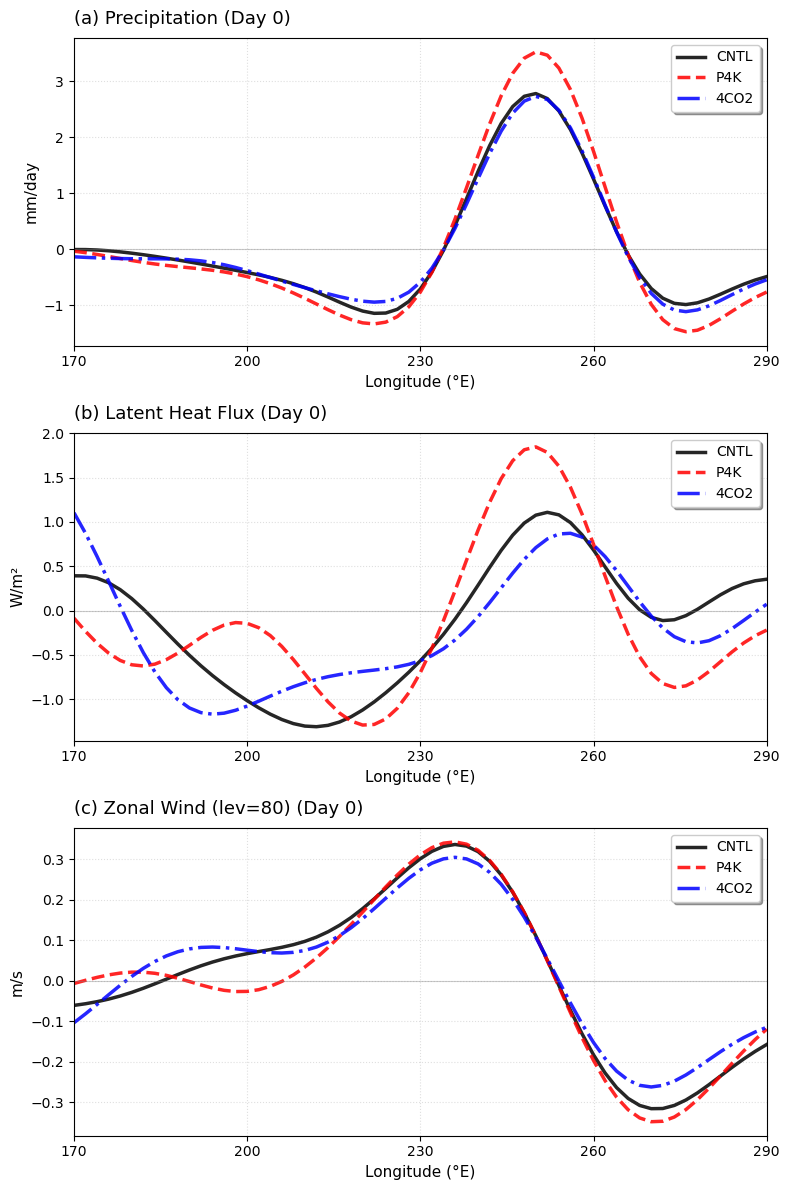


✅ Day 0 comparison completed!

📖 图像解读：
   • 3个子图：分别显示降水、潜热通量、纬向风
   • 曲线颜色：
     - 黑色实线：CNTL（控制实验）
     - 蓝色虚线：P4K（+4K SST）
     - 红色点划线：4CO2（4×CO2）

🔬 科学问题：
   1. 峰值振幅变化：
      - P4K和4CO2相比CNTL是增强还是减弱？
      - 三个变量的响应是否一致？
   2. 空间结构变化：
      - 峰值位置是否发生经度偏移？
      - 空间尺度（波长）是否改变？
   3. 变量关系：
      - 降水与潜热通量的峰值位置是否一致？
      - 纬向风异常与对流活动的配置关系


In [54]:
# ============================================================================
# 绘制Day 0对比图
# ============================================================================

print("\n" + "="*80)
print("🎨 Creating Day 0 (Peak Phase) Comparison")
print("="*80)
print(f"\n📍 Analysis Parameters:")
print(f"   Focus: Day 0 only (Event peak)")
print(f"   Latitude Averaging: {5}-{10}°N")
print(f"   Longitude Range: 170°E - 290°E")
print(f"   Zonal Wind Level: 80")
print(f"\n🔍 Purpose:")
print(f"   Compare peak amplitudes and spatial structures")
print(f"   across CNTL, P4K, and 4CO2 experiments")
print("="*80)
# ============================================================================
# 函数：绘制Day 0对比图（3个实验 × 3个变量）
# ============================================================================

def plot_day0_comparison(pr_composites, lhf_composites, ua_composites,
                        lat_avg=slice(5, 10),
                        lon_range=(170, 290),
                        lev=80,
                        figsize=(18, 6),
                        save_path=None):
    """
    绘制Day 0（峰值时刻）的经度剖面对比图
    
    布局：1行3列
    - 第1列：降水
    - 第2列：潜热通量
    - 第3列：纬向风
    每列显示3个实验的曲线对比
    
    Parameters:
    -----------
    pr_composites : dict
        降水合成数据
    lhf_composites : dict
        潜热通量合成数据  
    ua_composites : dict
        纬向风合成数据
    lat_avg : slice
        纬度平均范围
    lon_range : tuple
        经度范围
    lev : int
        纬向风的层次
    figsize : tuple
        图像大小
    save_path : str, optional
        保存路径
    
    Returns:
    --------
    fig, axes : matplotlib对象
    """
    
    exp_names = ['CNTL', 'P4K', '4CO2']
    exp_colors = {'CNTL': 'black', 'P4K': 'red', '4CO2': 'blue'}
    exp_linestyles = {'CNTL': '-', 'P4K': '--', '4CO2': '-.'}
    
    var_configs = [
        {'data': pr_composites, 'name': 'Precipitation', 'unit': 'mm/day', 'level': None},
        {'data': lhf_composites, 'name': 'Latent Heat Flux', 'unit': 'W/m²', 'level': None},
        {'data': ua_composites, 'name': f'Zonal Wind (lev={lev})', 'unit': 'm/s', 'level': lev}
    ]
    titles =['(a)','(b)','(c)']
    # 创建图形
    fig, axes = plt.subplots(3, 1, figsize=figsize)
    
    print("\n" + "="*80)
    print("🎨 Plotting Day 0 Comparison Across Experiments")
    print("="*80)
    
    for col_idx, var_config in enumerate(var_configs):
        ax = axes[col_idx]
        
        # 对每个实验绘制Day 0的曲线
        for exp in exp_names:
            # 获取数据
            composite = var_config['data'][exp]
            if var_config['level'] is not None:
                composite = composite.sel(lev=var_config['level'])
            
            # 选择Day 0
            data_day0 = composite.sel(lag=0)
            
            # 纬度平均
            data_lat_avg = data_day0.sel(lat=lat_avg).mean('lat')
            
            # 经度选择
            lons = data_lat_avg.lon.values
            lon_mask = (lons >= lon_range[0]) & (lons <= lon_range[1])
            data_lon_sel = data_lat_avg.isel(lon=lon_mask)
            lons_sel = lons[lon_mask]
            
            # 绘制曲线
            ax.plot(lons_sel, data_lon_sel.values,
                   color=exp_colors[exp],
                   linestyle=exp_linestyles[exp],
                   linewidth=2.5,
                   label=exp,
                   alpha=0.85)
        
        # 零线
        ax.axhline(y=0, color='gray', linestyle='-', 
                  linewidth=0.8, alpha=0.4)
        
        # 设置标题
        ax.set_title(f'{titles[col_idx]} {var_config["name"]} (Day 0)', loc='left',
                    fontsize=13, pad=10)
        
        # 设置Y轴标签
        ax.set_ylabel(var_config['unit'], fontsize=11)
        
        # 设置X轴标签
        ax.set_xlabel('Longitude (°E)', fontsize=11)
        
        # 设置经度范围和刻度
        ax.set_xlim(lon_range)
        ax.set_xticks(np.arange(lon_range[0], lon_range[1]+1, 30))
        
        # 网格
        ax.grid(True, linestyle=':', alpha=0.4)
        
        # 图例
        ax.legend(loc='best', fontsize=10, frameon=True, 
                 fancybox=True, shadow=True, ncol=1)
    

    
    plt.tight_layout()
    
    # 保存
    if save_path:
        save_file = os.path.join(save_path, 'day0_comparison_3exp_3var.png')
        fig.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"💾 Saved: {save_file}")
    
    print("✅ Day 0 comparison completed!")
    
    return fig, axes


print("✅ Day 0 comparison function defined")
# 调用绘图函数
fig_day0, axes_day0 = plot_day0_comparison(
    pr_composites=pr_composite_dict,
    lhf_composites=lhf_composite_dict,
    ua_composites=ua_composite_dict,
    lat_avg=slice(5, 10),
    lon_range=(170, 290),
    lev=80,
    figsize=(8, 12),
    save_path=FIG_SAVE_DIR
)

plt.show()

print("\n" + "="*80)
print("✅ Day 0 comparison completed!")
print("="*80)
print("\n📖 图像解读：")
print("   • 3个子图：分别显示降水、潜热通量、纬向风")
print("   • 曲线颜色：")
print("     - 黑色实线：CNTL（控制实验）")
print("     - 蓝色虚线：P4K（+4K SST）")
print("     - 红色点划线：4CO2（4×CO2）")
print("\n🔬 科学问题：")
print("   1. 峰值振幅变化：")
print("      - P4K和4CO2相比CNTL是增强还是减弱？")
print("      - 三个变量的响应是否一致？")
print("   2. 空间结构变化：")
print("      - 峰值位置是否发生经度偏移？")
print("      - 空间尺度（波长）是否改变？")
print("   3. 变量关系：")
print("      - 降水与潜热通量的峰值位置是否一致？")
print("      - 纬向风异常与对流活动的配置关系")
print("="*80)


🎨 Creating Time Evolution at Fixed Longitude

📍 Analysis Parameters:
   Fixed Longitude: 110°W (= 250°E)
   Latitude Averaging: 0-15°N
   Time Range: -4 to +4 days
   Zonal Wind Level: 80

🔍 Purpose:
   Observe how Kelvin wave passes through this fixed location
   Compare the timing and amplitude across experiments
✅ Fixed longitude time series function defined

🎨 Plotting Time Evolution at Fixed Longitude: 250°E


💾 Saved: ./figures/latent_heat_flux_composite/timeseries_fixed_lon250E_3exp_3var.png
✅ Fixed longitude time series completed!


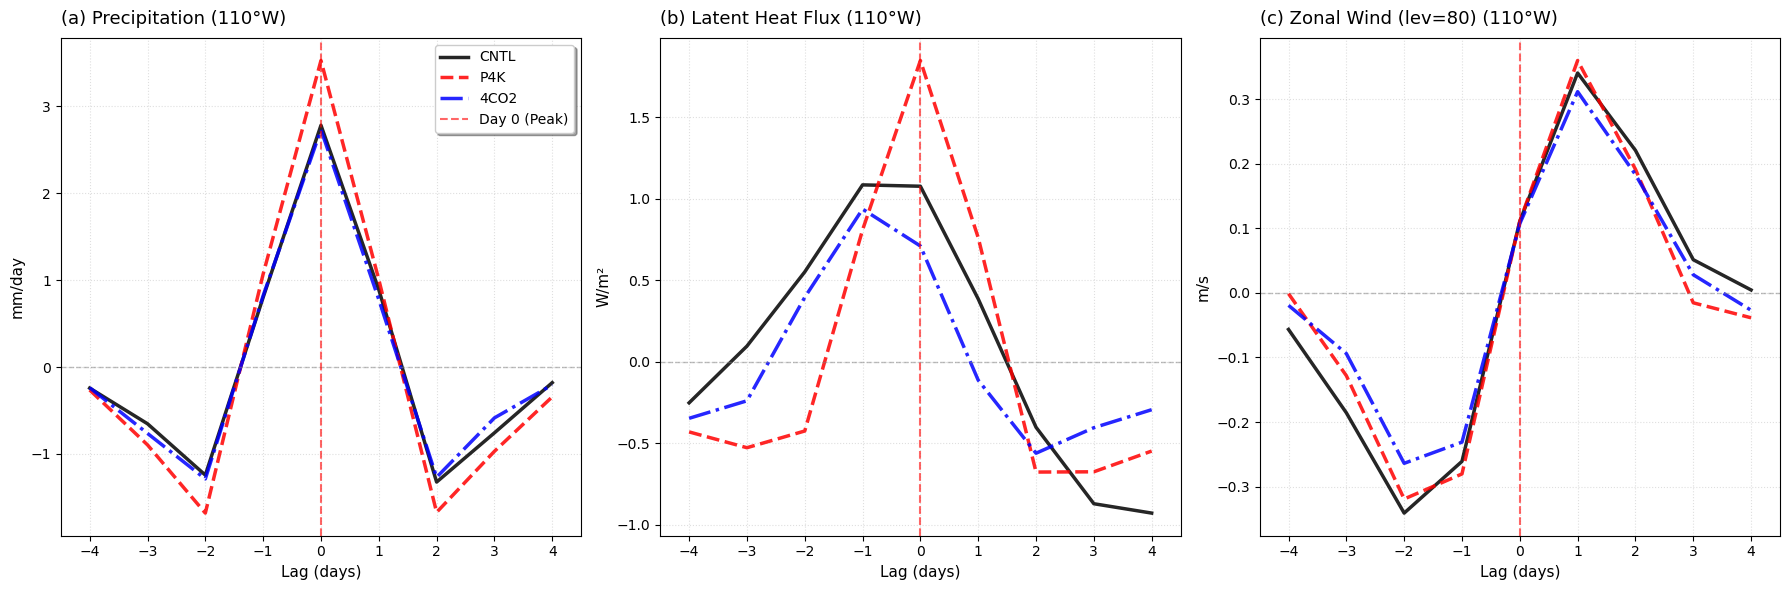


✅ Fixed longitude time series completed!

📖 图像解读：
   • 3个子图：分别显示降水、潜热通量、纬向风
   • 曲线/标记：
     - 黑色圆圈：CNTL
     - 蓝色方块：P4K
     - 红色三角：4CO2
   • 红色虚线：Day 0（事件峰值定义时刻）

🌊 物理解释：
   1. 波动传播：
      - 如果峰值出现在Day 0之前（负lag）：
        说明该位置在事件中心的东侧
      - 如果峰值出现在Day 0之后（正lag）：
        说明该位置在事件中心的西侧
   2. 振幅对比：
      - 比较三条曲线的峰值大小
      - 观察气候变化对波动强度的影响
   3. 时间演变：
      - 曲线形状反映波动经过该点的时间尺度
      - 对称性反映波动结构的对称性

💡 提示：
   • 110°W (250°E) 位于太平洋东部
   • 这是观测CCKW活动的关键区域之一


In [68]:
# ============================================================================
# 绘制固定经度位置（110°W = 250°E）的时间演变曲线
# ============================================================================

print("\n" + "="*80)
print("🎨 Creating Time Evolution at Fixed Longitude")
print("="*80)
print(f"\n📍 Analysis Parameters:")
print(f"   Fixed Longitude: 110°W (= 250°E)")
print(f"   Latitude Averaging: 0-15°N")
print(f"   Time Range: -4 to +4 days")
print(f"   Zonal Wind Level: 80")
print(f"\n🔍 Purpose:")
print(f"   Observe how Kelvin wave passes through this fixed location")
print(f"   Compare the timing and amplitude across experiments")
print("="*80)
# ============================================================================
# 函数：绘制固定经度位置的时间演变曲线
# ============================================================================

def plot_fixed_longitude_timeseries(pr_composites, lhf_composites, ua_composites,
                                   fixed_lon=250,  # 固定经度（注意：110°W = 250°E）
                                   lat_avg=slice(0, 15),
                                   lev=80,
                                   figsize=(18, 6),
                                   save_path=None):
    """
    绘制固定经度位置随时间（lag）的演变曲线
    
    布局：1行3列
    - 第1列：降水
    - 第2列：潜热通量
    - 第3列：纬向风
    每列显示3个实验的时间序列
    
    Parameters:
    -----------
    pr_composites : dict
        降水合成数据
    lhf_composites : dict
        潜热通量合成数据  
    ua_composites : dict
        纬向风合成数据
    fixed_lon : float
        固定的经度位置（度E）
        注意：110°W = 360° - 110° = 250°E
    lat_avg : slice
        纬度平均范围
    lev : int
        纬向风的层次
    figsize : tuple
        图像大小
    save_path : str, optional
        保存路径
    
    Returns:
    --------
    fig, axes : matplotlib对象
    """
    exp_names = ['CNTL', 'P4K', '4CO2']
    exp_colors = {'CNTL': 'black', 'P4K': 'red', '4CO2': 'blue'}
    exp_linestyles = {'CNTL': '-', 'P4K': '--', '4CO2': '-.'}
    var_configs = [
        {'data': pr_composites, 'name': 'Precipitation', 'unit': 'mm/day', 'level': None},
        {'data': lhf_composites, 'name': 'Latent Heat Flux', 'unit': 'W/m²', 'level': None},
        {'data': ua_composites, 'name': f'Zonal Wind (lev={lev})', 'unit': 'm/s', 'level': lev}
    ]
    titles =['(a)','(b)','(c)']
    # 创建图形
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    print("\n" + "="*80)
    print(f"🎨 Plotting Time Evolution at Fixed Longitude: {fixed_lon}°E")
    print("="*80)
    
    for col_idx, var_config in enumerate(var_configs):
        ax = axes[col_idx]
        
        # 对每个实验绘制时间序列
        for exp in exp_names:
            # 获取数据
            composite = var_config['data'][exp]
            if var_config['level'] is not None:
                composite = composite.sel(lev=var_config['level'])
            
            # 纬度平均
            data_lat_avg = composite.sel(lat=lat_avg).mean('lat')
            
            # 选择固定经度（最近的格点）
            data_fixed_lon = data_lat_avg.sel(lon=fixed_lon, method='nearest')
            
            # 获取lag维度
            lags = data_fixed_lon.lag.values
            values = data_fixed_lon.values
            
            # 绘制时间序列曲线
            ax.plot(lags, values,
                   color=exp_colors[exp],
                   linestyle=exp_linestyles[exp],
                   linewidth=2.5,
                   label=exp,
                   alpha=0.85)
        
        # 零线
        ax.axhline(y=0, color='gray', linestyle='--', 
                  linewidth=1, alpha=0.5)
        
        # Day 0 竖线
        ax.axvline(x=0, color='red', linestyle='--', 
                  linewidth=1.5, alpha=0.6, label='Day 0 (Peak)')
        
        # 设置标题
        ax.set_title(f'{titles[col_idx]} {var_config["name"]} (110°W)', loc='left',
                    fontsize=13, pad=10)
        
        # 设置Y轴标签
        ax.set_ylabel(var_config['unit'], fontsize=11)
        
        # 设置X轴
        ax.set_xlabel('Lag (days)', fontsize=11)
        ax.set_xlim([lags.min()-0.5, lags.max()+0.5])
        ax.set_xticks(lags)
        
        # 网格
        ax.grid(True, linestyle=':', alpha=0.4)
        
        # 图例
        if col_idx == 0:
            ax.legend(loc='best', fontsize=10, frameon=True, 
                     fancybox=True, shadow=True)
    
    plt.tight_layout()
    
    # 保存
    if save_path:
        save_file = os.path.join(save_path, f'timeseries_fixed_lon{fixed_lon}E_3exp_3var.png')
        fig.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"💾 Saved: {save_file}")
    
    print("✅ Fixed longitude time series completed!")
    
    return fig, axes


print("✅ Fixed longitude time series function defined")
# 调用绘图函数
# 注意：110°W = 360° - 110° = 250°E
fig_timeseries, axes_timeseries = plot_fixed_longitude_timeseries(
    pr_composites=pr_composite_dict,
    lhf_composites=lhf_composite_dict,
    ua_composites=ua_composite_dict,
    fixed_lon=250,           # 110°W = 250°E
    lat_avg=slice(5, 10),    # 纬度平均：0-15°N
    lev=80,
    figsize=(18, 6),
    save_path=FIG_SAVE_DIR
)

plt.show()

print("\n" + "="*80)
print("✅ Fixed longitude time series completed!")
print("="*80)
print("\n📖 图像解读：")
print("   • 3个子图：分别显示降水、潜热通量、纬向风")
print("   • 曲线/标记：")
print("     - 黑色圆圈：CNTL")
print("     - 蓝色方块：P4K")
print("     - 红色三角：4CO2")
print("   • 红色虚线：Day 0（事件峰值定义时刻）")
print("\n🌊 物理解释：")
print("   1. 波动传播：")
print("      - 如果峰值出现在Day 0之前（负lag）：")
print("        说明该位置在事件中心的东侧")
print("      - 如果峰值出现在Day 0之后（正lag）：")
print("        说明该位置在事件中心的西侧")
print("   2. 振幅对比：")
print("      - 比较三条曲线的峰值大小")
print("      - 观察气候变化对波动强度的影响")
print("   3. 时间演变：")
print("      - 曲线形状反映波动经过该点的时间尺度")
print("      - 对称性反映波动结构的对称性")
print("\n💡 提示：")
print("   • 110°W (250°E) 位于太平洋东部")
print("   • 这是观测CCKW活动的关键区域之一")
print("="*80)


🎨 Creating Longitude Profiles: All Variables by Experiment

📍 Analysis Parameters:
   Latitude Averaging: 5-10°N
   Longitude Range: 170°E - 290°E
   Lag Days: -4, -2, 0, +2, +4
   Zonal Wind Level: 80

📊 Layout:
   子图1: CNTL - 降水、潜热通量、风场
   子图2: P4K - 降水、潜热通量、风场
   子图3: 4CO2 - 降水、潜热通量、风场

🎨 Color Coding:
   蓝色: 降水 (Precipitation)
   红色: 潜热通量 (Latent Heat Flux)
   绿色: 纬向风 (Zonal Wind)

📏 Line Styles (by Lag):
   实线: Day 0 (最醒目)
   点划线: Day ±2
   虚线: Day ±4
✅ Time evolution at fixed longitude function defined

🎨 Plotting Time Evolution at Fixed Longitude: 250°E

📊 Processing CNTL...

📊 Processing P4K...

📊 Processing 4CO2...



💾 Saved: ./figures/latent_heat_flux_composite/timeseries_fixed_lon250E_all_vars_by_exp.png

✅ Time evolution plot completed!


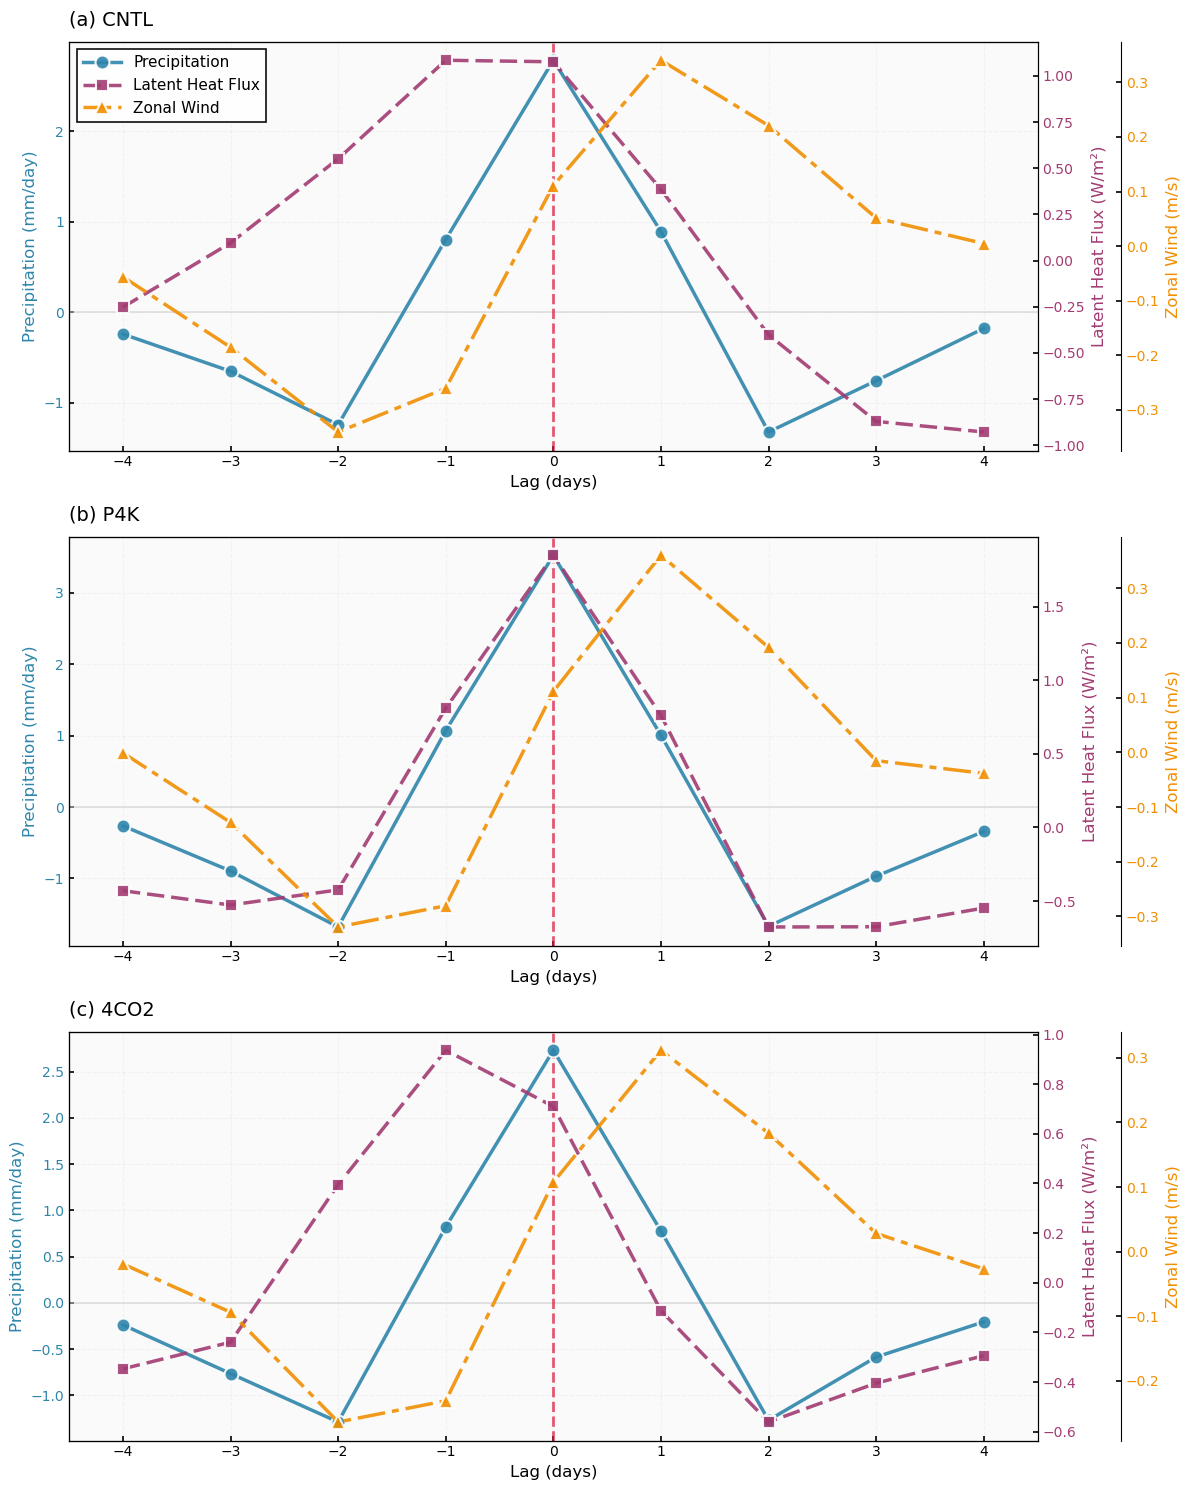

In [81]:

# ============================================================================
# 绘制所有变量按实验分组的经度剖面图
# ============================================================================

print("\n" + "="*80)
print("🎨 Creating Longitude Profiles: All Variables by Experiment")
print("="*80)
print(f"\n📍 Analysis Parameters:")
print(f"   Latitude Averaging: {5}-{10}°N")
print(f"   Longitude Range: 170°E - 290°E")
print(f"   Lag Days: -4, -2, 0, +2, +4")
print(f"   Zonal Wind Level: 80")
print(f"\n📊 Layout:")
print(f"   子图1: CNTL - 降水、潜热通量、风场")
print(f"   子图2: P4K - 降水、潜热通量、风场")
print(f"   子图3: 4CO2 - 降水、潜热通量、风场")
print(f"\n🎨 Color Coding:")
print(f"   蓝色: 降水 (Precipitation)")
print(f"   红色: 潜热通量 (Latent Heat Flux)")
print(f"   绿色: 纬向风 (Zonal Wind)")
print(f"\n📏 Line Styles (by Lag):")
print(f"   实线: Day 0 (最醒目)")
print(f"   点划线: Day ±2")
print(f"   虚线: Day ±4")
print("="*80)
# ============================================================================
# 函数：绘制每个实验的所有变量经度剖面（3行布局）
# ============================================================================

def plot_all_variables_by_experiment(pr_composites, lhf_composites, ua_composites,
                                     fixed_lon=250,  # 110°W = 250°E
                                     lat_avg=slice(0, 15),
                                     lev=80,
                                     figsize=(12, 15),
                                     save_path=None):
    """
    绘制固定经度位置的时间演变曲线，每个实验单独一个子图，在该子图中叠加三个变量
    
    布局：3行1列
    - 第1行：CNTL实验（降水 + 潜热通量 + 风场）随时间演变
    - 第2行：P4K实验（降水 + 潜热通量 + 风场）随时间演变
    - 第3行：4CO2实验（降水 + 潜热通量 + 风场）随时间演变
    
    Parameters:
    -----------
    pr_composites : dict
        降水合成数据 {exp_name: xr.DataArray}
    lhf_composites : dict
        潜热通量合成数据
    ua_composites : dict
        纬向风合成数据
    fixed_lon : float
        固定的经度位置（度E），默认250°E (= 110°W)
    lat_avg : slice
        纬度平均范围，默认0-15°N
    lev : int
        纬向风的层次
    figsize : tuple
        图像大小
    save_path : str, optional
        保存路径
    
    Returns:
    --------
    fig, axes : matplotlib对象
    """
    
    exp_names = ['CNTL', 'P4K', '4CO2']
    panel_labels = ['(a)', '(b)', '(c)']

    # 使用更专业的学术配色方案
    var_styles = {
        'pr': {
            'color': '#2E86AB',      # 深蓝色 - 代表降水
            'marker': 'o', 
            'markersize': 10,
            'markeredgewidth': 1.5,
            'markeredgecolor': 'white',
            'label': 'Precipitation',
            'linestyle': '-',
            'linewidth': 2.5
        },
        'lhf': {
            'color': '#A23B72',      # 深紫红色 - 代表热通量
            'marker': 's', 
            'markersize': 9,
            'markeredgewidth': 1.5,
            'markeredgecolor': 'white',
            'label': 'Latent Heat Flux',
            'linestyle': (0, (5, 2)),  # 自定义虚线样式
            'linewidth': 2.5
        },
        'ua': {
            'color': '#F18F01',      # 橙色 - 代表风场
            'marker': '^', 
            'markersize': 10,
            'markeredgewidth': 1.5,
            'markeredgecolor': 'white',
            'label': 'Zonal Wind',
            'linestyle': (0, (8, 2, 2, 2)),  # 自定义点划线样式
            'linewidth': 2.5
        }
    }
    
    # 创建图形
    fig, axes = plt.subplots(3, 1, figsize=figsize)
    
    print("\n" + "="*80)
    print(f"🎨 Plotting Time Evolution at Fixed Longitude: {fixed_lon}°E")
    print("="*80)
    
    for row_idx, exp in enumerate(exp_names):
        ax = axes[row_idx]
        
        # 为每个变量创建额外的y轴
        ax2 = ax.twinx()  # 潜热通量
        ax3 = ax.twinx()  # 风场
        
        # 调整第三个y轴的位置，使其不与第二个重叠
        ax3.spines['right'].set_position(('outward', 60))
        
        print(f"\n📊 Processing {exp}...")
        
        # 变量配置
        var_data_list = [
            {'composite': pr_composites[exp], 'level': None, 'axis': ax, 
             'style': var_styles['pr'], 'unit': 'mm/day',
             'linestyle': '-'
             },
            {'composite': lhf_composites[exp], 'level': None, 'axis': ax2,
             'style': var_styles['lhf'], 'unit': 'W/m²',
              'linestyle': '--'
             },
            {'composite': ua_composites[exp], 'level': lev, 'axis': ax3,
             'style': var_styles['ua'], 'unit': 'm/s',
              'linestyle': '-.'}
        ]
        
        # 绘制每个变量的时间序列
        for var_data in var_data_list:
            composite = var_data['composite']
            if var_data['level'] is not None:
                composite = composite.sel(lev=var_data['level'])
            
            # 纬度平均
            data_lat_avg = composite.sel(lat=lat_avg).mean('lat')
            
            # 选择固定经度（最近的格点）
            data_fixed_lon = data_lat_avg.sel(lon=fixed_lon, method='nearest')
            
            # 获取lag维度和数值
            lags = data_fixed_lon.lag.values
            values = data_fixed_lon.values
            
            style = var_data['style']
            
            # 在对应的轴上绘制时间序列（更精细的样式控制）
            var_data['axis'].plot(
                lags, values,
                color=style['color'],
                marker=style['marker'],
                markersize=style['markersize'],
                markeredgewidth=style['markeredgewidth'],
                markeredgecolor=style['markeredgecolor'],
                markerfacecolor=style['color'],
                linestyle=style['linestyle'],
                linewidth=style['linewidth'],
                label=style['label'],
                alpha=0.9,
                zorder=3  # 确保线条在网格之上
            )
        
        # 零线（更细致的样式）
        ax.axhline(y=0, color='#CCCCCC', linestyle='-', linewidth=1.2, alpha=0.6, zorder=1)
        
        # Day 0 竖线（更醒目）
        ax.axvline(x=0, color='#DC143C', linestyle='--', linewidth=2, alpha=0.7, zorder=2)
        
        # 设置标题（带(a)标签，居左）
        ax.set_title(f'{panel_labels[row_idx]} {exp}', 
                    fontsize=14, loc='left', pad=12)
        
        # 设置X轴
        ax.set_xlabel('Lag (days)', fontsize=12)
        ax.set_xlim([lags.min()-0.5, lags.max()+0.5])
        ax.set_xticks(lags)
        ax.tick_params(axis='x', labelsize=10, direction='in', width=1.2)
        
        # 设置Y轴标签和颜色
        ax.set_ylabel('Precipitation (mm/day)', fontsize=12, 
                     color=var_styles['pr']['color'])
        ax2.set_ylabel('Latent Heat Flux (W/m²)', fontsize=12,
                      color=var_styles['lhf']['color'])
        ax3.set_ylabel('Zonal Wind (m/s)', fontsize=12,
                      color=var_styles['ua']['color'])
        
        # 设置刻度标签颜色和样式
        ax.tick_params(axis='y', labelcolor=var_styles['pr']['color'], 
                      labelsize=10, direction='in', width=1.2)
        ax2.tick_params(axis='y', labelcolor=var_styles['lhf']['color'],
                       labelsize=10, direction='in', width=1.2)
        ax3.tick_params(axis='y', labelcolor=var_styles['ua']['color'],
                       labelsize=10, direction='in', width=1.2)
        
        # 更精细的网格样式
        ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.8, color='#DDDDDD', zorder=0)
        ax.set_axisbelow(True)  # 网格在数据之下
        
        # 添加轻微的背景色以区分不同子图
        ax.set_facecolor('#FAFAFA')
        
        # 图例（合并所有轴的图例，更美观的样式）
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        lines3, labels3 = ax3.get_legend_handles_labels()
        
        # 只在第一个子图显示图例
        if row_idx == 0:
            legend = ax.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
                             loc='upper left', fontsize=11, frameon=True, 
                             fancybox=False, shadow=False, 
                             edgecolor='black', framealpha=0.95,
                             ncol=1, columnspacing=1.0, handlelength=2.5)
            legend.get_frame().set_linewidth(1.2)
    
    plt.tight_layout()
    
    # 保存（更高分辨率）
    if save_path:
        save_file = os.path.join(save_path, f'timeseries_fixed_lon{fixed_lon}E_all_vars_by_exp.png')
        fig.savefig(save_file, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='none')
        print(f"\n💾 Saved: {save_file}")
    
    print("\n✅ Time evolution plot completed!")
    
    return fig, axes


print("✅ Time evolution at fixed longitude function defined")
# 调用绘图函数
fig_all_vars, axes_all_vars = plot_all_variables_by_experiment(
    pr_composites=pr_composite_dict,
    lhf_composites=lhf_composite_dict,
    ua_composites=ua_composite_dict,
    fixed_lon=250,           # 110°W = 250°E
    lat_avg=slice(5, 10),    # 纬度平均：0-15°N
    lev=80,
    figsize=(12, 15),
    save_path=FIG_SAVE_DIR
)

plt.show()

print("="*80)